# 📊 Comprehensive Analysis for Top-Tier Conference Paper
## Project TRIAD: LLM Behavior Under Noise in Multi-Agent Game Theory

**Target Venue:** UAI 2026 / NeurIPS 2026 / AAAI 2026

### Research Questions
1. **The Trembling Paradox:** Does execution noise (trembling hand) *increase* cooperation in LLM agents?
2. **Cross-Model Behavioral Divergence:** How do different LLMs (Mistral-7B, Qwen-32B, GPT-oss-20B) differ in strategic behavior?
3. **Personality-Strategy Alignment:** Do cooperative/selfish prompts reliably control LLM behavior?
4. **Multilingual Robustness:** Is LLM game-theoretic behavior consistent across 6 languages?
5. **Noise Attribution & Hallucination:** Can LLMs distinguish strategic moves from random noise?

### Key Contributions (vs. ICWSM'25 baseline)
| This Paper | ICWSM'25 (Fontana et al.) |
|---|---|
| 3 LLMs with noise injection | 3 LLMs without noise |
| 2P + 3P Prisoner's Dilemma | 2P only |
| 6 languages (EN, FR, AR, CN, VN, IT) | English only |
| Trembling Robustness Score (TRS) | No noise analysis |
| Personality-driven agents (cooperative/selfish) | No personality manipulation |
| LSTM + Rule-based strategy detection | SFEM only |

### Analysis Pipeline
1. **Data Loading & Preprocessing** — Load 1680 games across 3 models × 3 noise levels × 6 languages
2. **Cooperation Rate Analysis** — Overall + per model/noise/personality/language
3. **Trembling Robustness Score (TRS)** — Novel metric: cooperation slope vs. noise
4. **Strategy Detection** — LSTM + Rule-based combined pipeline
5. **Behavioral Profile** — 5 dimensions (Nice, Forgiving, Retaliatory, Troublemaking, Emulative)
6. **SFEM Analysis** — Strategy Frequency Estimation Method
7. **Noise Impact Analysis** — Intended vs. actual cooperation, flip analysis
8. **Comprehension & Hallucination** — Checker accuracy analysis
9. **Statistical Tests** — Kruskal-Wallis, Mann-Whitney, Spearman, effect sizes
10. **3-Player Analysis** — State distribution, coalition patterns
11. **Paper-Ready Figures** — Publication-quality visualizations

In [1]:
# ============================================================================
# PART 1: IMPORTS & CONFIGURATION
# ============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu, spearmanr, chi2_contingency
from collections import Counter
import warnings, os, sys, json
from itertools import combinations

# Add project root to path
sys.path.insert(0, os.path.abspath('.'))

warnings.filterwarnings('ignore')

# Publication-quality settings
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,  # Avoid Type 3 fonts
    'ps.fonttype': 42,
    'font.family': 'sans-serif',
})

# Color palette for models
MODEL_COLORS = {
    'Mistral-7B-Instruct-v0.3': '#1f77b4',
    'Qwen2.5-32B-Instruct': '#ff7f0e', 
    'gpt-oss-20b': '#2ca02c'
}
MODEL_SHORT = {
    'Mistral-7B-Instruct-v0.3': 'Mistral-7B',
    'Qwen2.5-32B-Instruct': 'Qwen-32B',
    'gpt-oss-20b': 'GPT-oss-20B'
}
NOISE_COLORS = {0: '#2ca02c', 5: '#ff7f0e', 20: '#d62728'}
PERSONALITY_COLORS = {'cooperative': '#1f77b4', 'selfish': '#d62728', 'mixed': '#9467bd'}

# Multilingual cooperation keywords
COOP_KEYWORDS = ['Cooperate', 'cooperate', 'C', 'Hop tac', 
                 'cooperer', 'Cooperare', 'cooperare',
                 'تعاون', '合作']
DEFECT_KEYWORDS = ['Defect', 'defect', 'D', 'Phan boi',
                   'Trahir', 'trahir', 'Tradire', 'tradire', 
                   'خيانة', '背叛']

FIGURES_DIR = 'figures/paper_analysis'
os.makedirs(FIGURES_DIR, exist_ok=True)
print("Imports and configuration loaded successfully")

Imports and configuration loaded successfully


## Part 2: Data Loading & Preprocessing
Load the complete dataset: **1680 games** across 3 LLMs, 3 noise levels, 6 languages, 2 personality types.

In [2]:
# ============================================================================
# PART 2: DATA LOADING & PREPROCESSING
# ============================================================================

# Load game-level summary
df_games = pd.read_csv('resources/results/Prisoner_dilemma_2player/total_games_summary.csv')

# Load round-level details
df_rounds = pd.read_csv('resources/results/Prisoner_dilemma_2player/total_rounds_detail.csv')

# Load checker results
df_checkers = pd.read_csv('resources/results/Prisoner_dilemma_2player/total_checker_results.csv')

# --- Normalize personality labels across languages ---
COOP_PERSONALITIES = ['cooperative', 'coopératif', 'cooperativo', 'متعاون', '合作型的', 'một người hợp tác']
SELFISH_PERSONALITIES = ['selfish', 'égoïste', 'egoista', 'أناني', '自私型的', 'một người ích kỷ']

def normalize_personality(p):
    if p in COOP_PERSONALITIES: return 'cooperative'
    if p in SELFISH_PERSONALITIES: return 'selfish'
    return p

df_games['agent1_personality_norm'] = df_games['agent1_personality'].apply(normalize_personality)
df_games['agent2_personality_norm'] = df_games['agent2_personality'].apply(normalize_personality)

# Create matchup type
def get_matchup(row):
    p1, p2 = sorted([row['agent1_personality_norm'], row['agent2_personality_norm']])
    if p1 == 'cooperative' and p2 == 'cooperative': return 'Coop vs Coop'
    elif p1 == 'selfish' and p2 == 'selfish': return 'Self vs Self'
    else: return 'Coop vs Self'

df_games['matchup'] = df_games.apply(get_matchup, axis=1)

# Short model names
df_games['model'] = df_games['llm_name'].map(MODEL_SHORT)

# Parse strategy lists
def parse_strategies(s):
    if isinstance(s, str):
        return [x.strip() for x in s.split(',')]
    return []

df_games['agent1_strats'] = df_games['agent1_strategies'].apply(parse_strategies)
df_games['agent2_strats'] = df_games['agent2_strategies'].apply(parse_strategies)
df_games['agent1_intended'] = df_games['agent1_intended_strategies'].apply(parse_strategies)
df_games['agent2_intended'] = df_games['agent2_intended_strategies'].apply(parse_strategies)

# Normalize round-level personalities
if 'agent_personality' in df_rounds.columns:
    df_rounds['personality_norm'] = df_rounds['agent_personality'].apply(normalize_personality)

print(f"=== Dataset Summary ===")
print(f"Total 2P games: {len(df_games)}")
print(f"Total rounds records: {len(df_rounds)}")
print(f"Models: {list(df_games['llm_name'].unique())}")
print(f"Noise levels: {sorted(df_games['noise_level'].unique())}")
print(f"Languages: {list(df_games['language'].unique())}")
print(f"\nGames per model:")
print(df_games['model'].value_counts().to_string())
print(f"\nGames per noise level:")
print(df_games['noise_level'].value_counts().sort_index().to_string())
print(f"\nGames per language:")
print(df_games['language'].value_counts().to_string())
print(f"\nGames per matchup:")
print(df_games['matchup'].value_counts().to_string())

=== Dataset Summary ===
Total 2P games: 1680
Total rounds records: 100800
Models: ['Mistral-7B-Instruct-v0.3', 'Qwen2.5-32B-Instruct', 'gpt-oss-20b']
Noise levels: [np.int64(0), np.int64(5), np.int64(20)]
Languages: ['en', 'fr', 'ar', 'cn', 'vn', 'it']

Games per model:
model
Qwen-32B       720
Mistral-7B     480
GPT-oss-20B    480

Games per noise level:
noise_level
0     720
5     720
20    240

Games per language:
language
en    280
fr    280
ar    280
cn    280
vn    280
it    280

Games per matchup:
matchup
Coop vs Self    840
Self vs Self    420
Coop vs Coop    420


## Part 3: Overall Cooperation Rate Analysis
### RQ1: How cooperative are LLMs? Does noise change cooperation?

Key metric: **Cooperation Rate** = fraction of rounds where agent chose Cooperate.

Inspired by ICWSM'25's $p_{coop}$ analysis but extended with:
- Noise level as independent variable
- Personality as moderating variable
- Cross-linguistic comparison

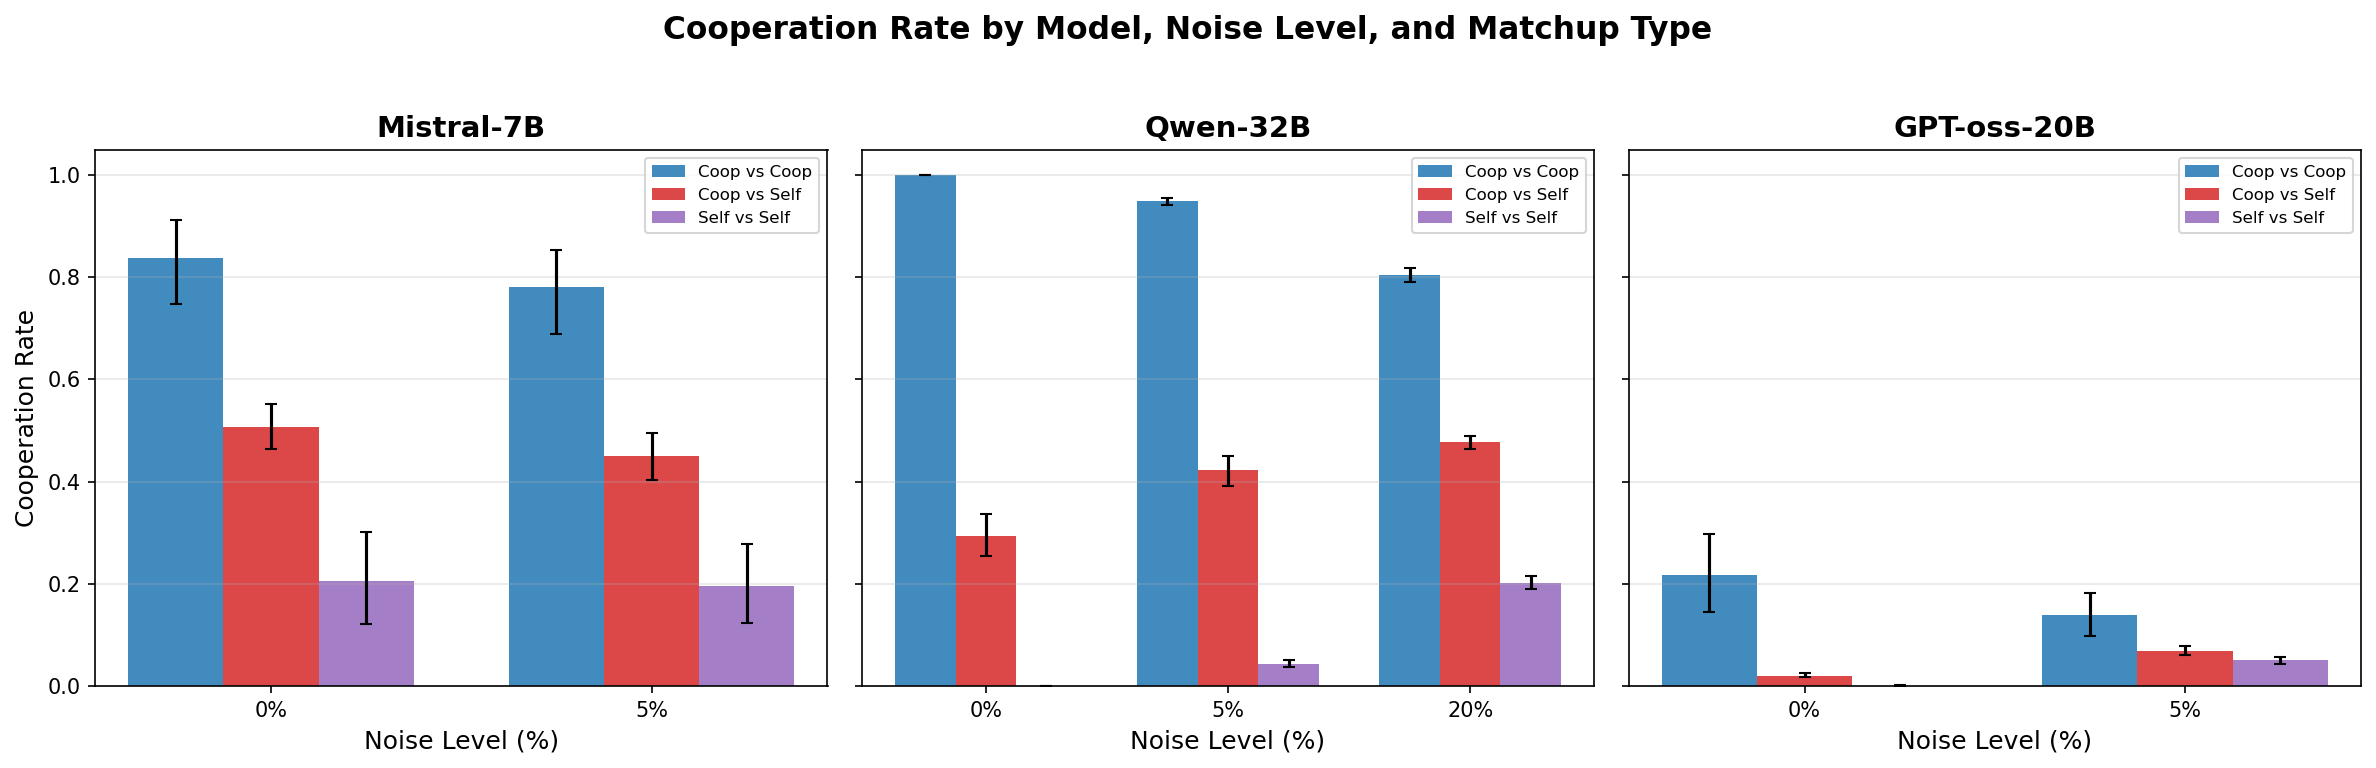


=== Key Cooperation Statistics ===
  Mistral-7B | Noise= 0% | Coop Rate: 0.515 [0.464, 0.564]
  Mistral-7B | Noise= 5% | Coop Rate: 0.469 [0.424, 0.517]
    Qwen-32B | Noise= 0% | Coop Rate: 0.397 [0.349, 0.449]
    Qwen-32B | Noise= 5% | Coop Rate: 0.459 [0.416, 0.501]
    Qwen-32B | Noise=20% | Coop Rate: 0.491 [0.461, 0.519]
 GPT-oss-20B | Noise= 0% | Coop Rate: 0.065 [0.045, 0.088]
 GPT-oss-20B | Noise= 5% | Coop Rate: 0.082 [0.071, 0.095]


In [3]:
# ============================================================================
# PART 3: COOPERATION RATE ANALYSIS
# ============================================================================

def bootstrap_ci(data, n_boot=1000, ci=0.95):
    """Bootstrap confidence interval."""
    if len(data) == 0:
        return np.nan, np.nan, np.nan
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    alpha = 1 - ci
    return np.mean(data), np.percentile(means, alpha/2*100), np.percentile(means, (1-alpha/2)*100)

# Compute average cooperation per game (average of both agents)
df_games['avg_coop_rate'] = (df_games['agent1_cooperation_rate'] + df_games['agent2_cooperation_rate']) / 2

# --- Figure 1: Cooperation Rate by Model × Noise Level (Main Result) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[idx]
    model_data = df_games[df_games['llm_name'] == model]
    
    noise_levels = sorted(model_data['noise_level'].unique())
    matchups = ['Coop vs Coop', 'Coop vs Self', 'Self vs Self']
    
    x = np.arange(len(noise_levels))
    width = 0.25
    
    for j, matchup in enumerate(matchups):
        means, lowers, uppers = [], [], []
        for noise in noise_levels:
            subset = model_data[(model_data['noise_level'] == noise) & (model_data['matchup'] == matchup)]
            m, lo, hi = bootstrap_ci(subset['avg_coop_rate'].values)
            means.append(m if not np.isnan(m) else 0)
            lowers.append(m - lo if not np.isnan(lo) else 0)
            uppers.append(hi - m if not np.isnan(hi) else 0)
        
        bars = ax.bar(x + j*width, means, width, 
                     yerr=[lowers, uppers], capsize=3,
                     label=matchup, alpha=0.85,
                     color=list(PERSONALITY_COLORS.values())[j])
    
    ax.set_xlabel('Noise Level (%)')
    ax.set_ylabel('Cooperation Rate' if idx == 0 else '')
    ax.set_title(MODEL_SHORT[model], fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels([f'{n}%' for n in noise_levels])
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cooperation Rate by Model, Noise Level, and Matchup Type', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_cooperation_by_model_noise_matchup.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig1_cooperation_by_model_noise_matchup.png', bbox_inches='tight')
plt.show()

# --- Print key statistics ---
print("\n=== Key Cooperation Statistics ===")
for model in sorted(df_games['llm_name'].unique()):
    model_data = df_games[df_games['llm_name'] == model]
    for noise in sorted(model_data['noise_level'].unique()):
        subset = model_data[model_data['noise_level'] == noise]
        m, lo, hi = bootstrap_ci(subset['avg_coop_rate'].values)
        print(f"{MODEL_SHORT[model]:>12s} | Noise={noise:>2d}% | Coop Rate: {m:.3f} [{lo:.3f}, {hi:.3f}]")

## Part 4: The Trembling Paradox — TRS (Trembling Robustness Score)
### Novel Contribution: Does noise *increase* cooperation?

**TRS** = $\frac{\partial(\text{CooperationRate})}{\partial\varepsilon}$ — linear regression slope of cooperation rate vs. noise level.

- **TRS > 0**: Noise *increases* cooperation (The Trembling Paradox)
- **TRS < 0**: Noise *decreases* cooperation (expected behavior)
- **TRS ≈ 0**: Noise-robust behavior

This is a key novel metric not present in ICWSM'25.

=== TRS (Trembling Robustness Score) per Model ===
          Model |  TRS (slope) |       R² |    p-value | Interpretation
---------------------------------------------------------------------------
     Mistral-7B |      -0.9043 |   1.0000 |     0.0000 | Noise hurts
       Qwen-32B |      +0.4081 |   0.7944 |     0.2996 | No significant effect
    GPT-oss-20B |      +0.3459 |   1.0000 |     0.0000 | PARADOX (noise helps!)

=== TRS per Model × Personality ===
          Model |  Personality |      TRS |    p-value
------------------------------------------------------------
     Mistral-7B |  cooperative |  -1.0834 |     0.0000
     Mistral-7B |      selfish |  -0.7251 |     0.0000
       Qwen-32B |  cooperative |  -0.1254 |     0.6196
       Qwen-32B |      selfish |  +0.9417 |     0.1531
    GPT-oss-20B |  cooperative |  -0.3388 |     0.0000
    GPT-oss-20B |      selfish |  +1.0306 |     0.0000


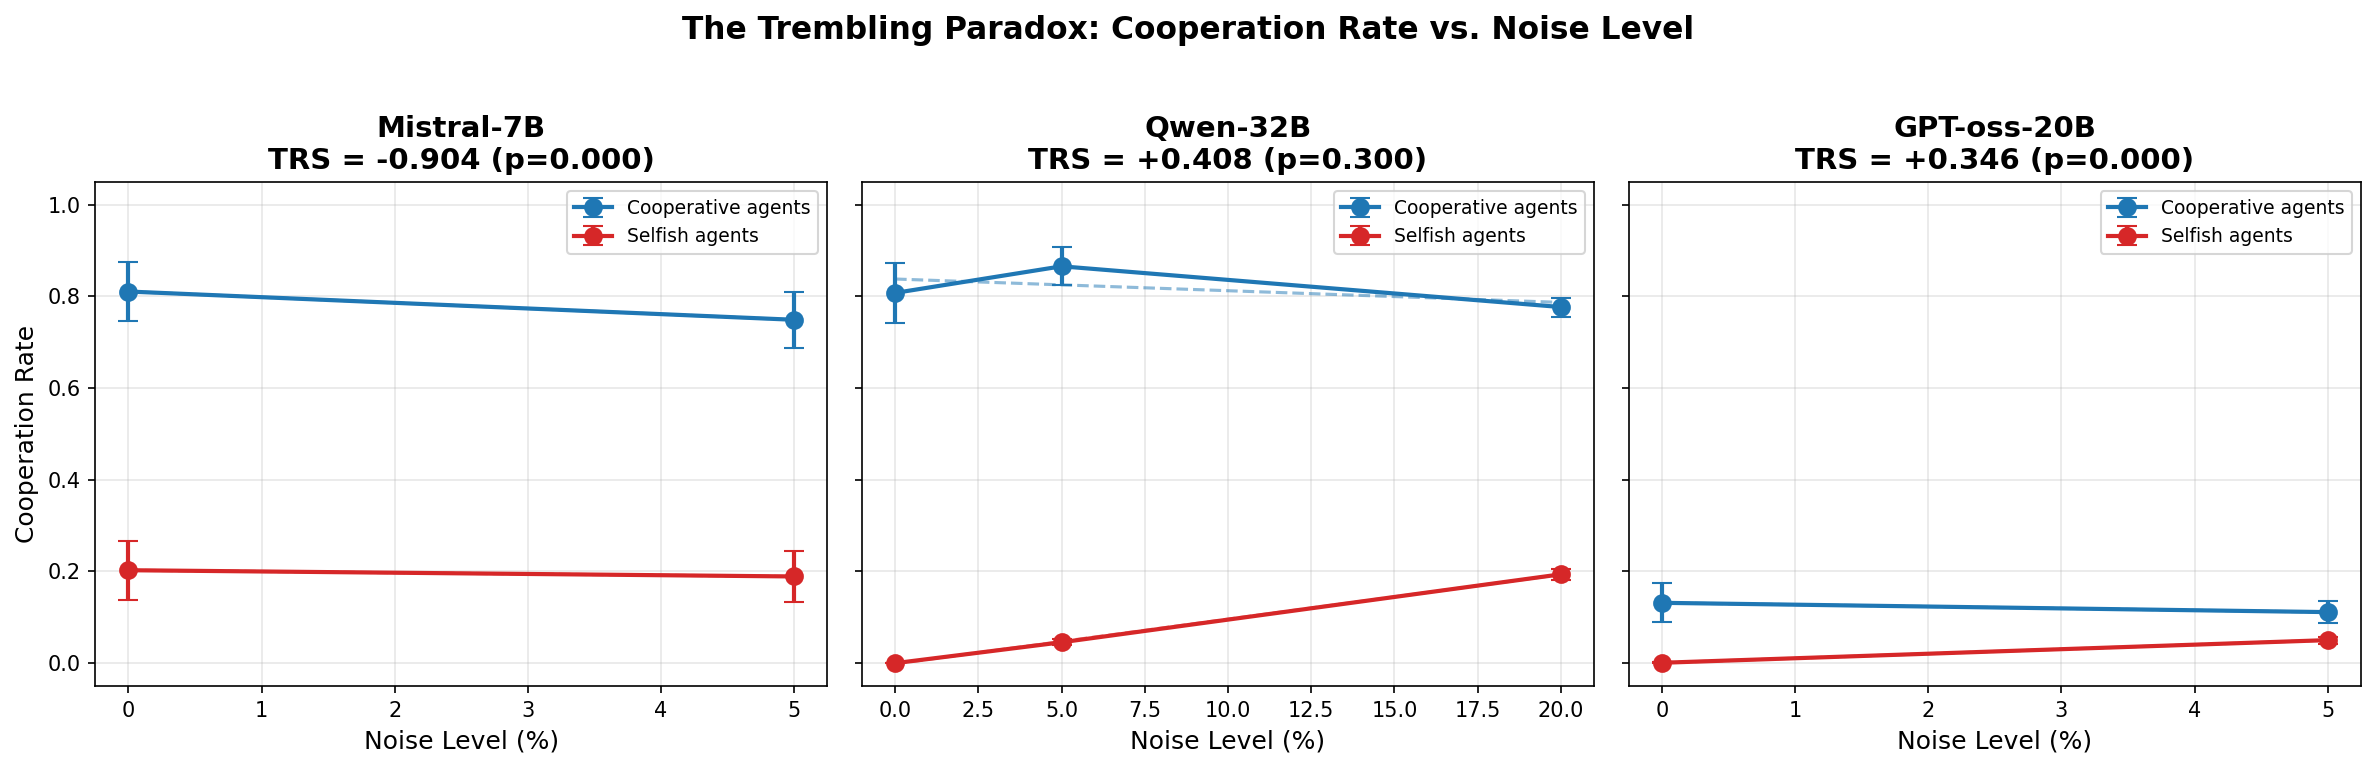


=== TRS per Language ===
  Language |      TRS |    p-value
-----------------------------------
        ar |  +0.1516 |     0.2935
        cn |  +0.8277 |     0.1328
        en |  +1.1822 |     0.0087
        fr |  +0.7678 |     0.1909
        it |  +0.7352 |     0.0307
        vn |  +1.5633 |     0.1766


In [4]:
# ============================================================================
# PART 4: TREMBLING ROBUSTNESS SCORE (TRS)
# ============================================================================

def calculate_trs(df_subset):
    """Calculate TRS via linear regression of cooperation rate vs noise."""
    grouped = df_subset.groupby('noise_level')['avg_coop_rate'].agg(['mean', 'std', 'count']).reset_index()
    if len(grouped) < 2:
        return {'slope': np.nan, 'r2': np.nan, 'p': np.nan, 'stderr': np.nan}
    x = grouped['noise_level'].values / 100.0  # Normalize to [0, 1]
    y = grouped['mean'].values
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    return {'slope': slope, 'intercept': intercept, 'r2': r_value**2, 'p': p_value, 'stderr': std_err}

# --- TRS per Model ---
print("=== TRS (Trembling Robustness Score) per Model ===")
print(f"{'Model':>15s} | {'TRS (slope)':>12s} | {'R²':>8s} | {'p-value':>10s} | {'Interpretation'}")
print("-" * 75)

trs_results = {}
for model in sorted(df_games['llm_name'].unique()):
    model_data = df_games[df_games['llm_name'] == model]
    trs = calculate_trs(model_data)
    trs_results[model] = trs
    interp = "PARADOX (noise helps!)" if trs['slope'] > 0 and trs['p'] < 0.05 else \
             "Noise hurts" if trs['slope'] < 0 and trs['p'] < 0.05 else "No significant effect"
    print(f"{MODEL_SHORT[model]:>15s} | {trs['slope']:>+12.4f} | {trs['r2']:>8.4f} | {trs['p']:>10.4f} | {interp}")

# --- TRS per Model × Personality ---
print("\n=== TRS per Model × Personality ===")
print(f"{'Model':>15s} | {'Personality':>12s} | {'TRS':>8s} | {'p-value':>10s}")
print("-" * 60)

for model in sorted(df_games['llm_name'].unique()):
    for pers in ['cooperative', 'selfish']:
        subset = df_games[(df_games['llm_name'] == model) & 
                          (df_games['agent1_personality_norm'] == pers)]
        if len(subset) > 0:
            trs = calculate_trs(subset)
            print(f"{MODEL_SHORT[model]:>15s} | {pers:>12s} | {trs['slope']:>+8.4f} | {trs['p']:>10.4f}")

# --- Figure 2: TRS Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[idx]
    model_data = df_games[df_games['llm_name'] == model]
    
    for pers, color in [('cooperative', '#1f77b4'), ('selfish', '#d62728')]:
        subset = model_data[model_data['agent1_personality_norm'] == pers]
        grouped = subset.groupby('noise_level')['agent1_cooperation_rate']
        means = grouped.mean()
        stds = grouped.std()
        counts = grouped.count()
        cis = 1.96 * stds / np.sqrt(counts)
        
        ax.errorbar(means.index, means.values, yerr=cis.values,
                    marker='o', capsize=5, linewidth=2, color=color,
                    label=f'{pers.capitalize()} agents', markersize=8)
        
        # Add regression line
        if len(means) >= 2:
            z = np.polyfit(means.index, means.values, 1)
            p = np.poly1d(z)
            x_line = np.linspace(means.index.min(), means.index.max(), 100)
            ax.plot(x_line, p(x_line), '--', color=color, alpha=0.5)
    
    trs = trs_results[model]
    ax.set_title(f"{MODEL_SHORT[model]}\nTRS = {trs['slope']:+.3f} (p={trs['p']:.3f})", fontweight='bold')
    ax.set_xlabel('Noise Level (%)')
    ax.set_ylabel('Cooperation Rate' if idx == 0 else '')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('The Trembling Paradox: Cooperation Rate vs. Noise Level', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_trembling_paradox_trs.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig2_trembling_paradox_trs.png', bbox_inches='tight')
plt.show()

# --- TRS per Language ---
print("\n=== TRS per Language ===")
print(f"{'Language':>10s} | {'TRS':>8s} | {'p-value':>10s}")
print("-" * 35)
for lang in sorted(df_games['language'].unique()):
    lang_data = df_games[df_games['language'] == lang]
    trs = calculate_trs(lang_data)
    if not np.isnan(trs['slope']):
        print(f"{lang:>10s} | {trs['slope']:>+8.4f} | {trs['p']:>10.4f}")

## Part 5: Behavioral Profile Analysis (5 Dimensions)
### Adapted from Romero & Rosokha (2018), as used in ICWSM'25

Five behavioral dimensions characterize LLM strategic behavior:

| Dimension | Definition | Value Range |
|---|---|---|
| **Nice** | Never defects first | Binary (0 or 1) |
| **Forgiving** | Resumes cooperation after opponent defects | [0, 1] |
| **Retaliatory** | Defects after unprovoked opponent defection | [0, 1] |
| **Troublemaking** | Defects when opponent cooperated | [0, 1] |
| **Emulative** | Copies opponent's previous action (TFT-like) | [0, 1] |

**Novel extension:** We analyze how these dimensions change under noise — this was NOT studied in ICWSM'25.

Behavioral profiles computed for 3360 agent-game pairs


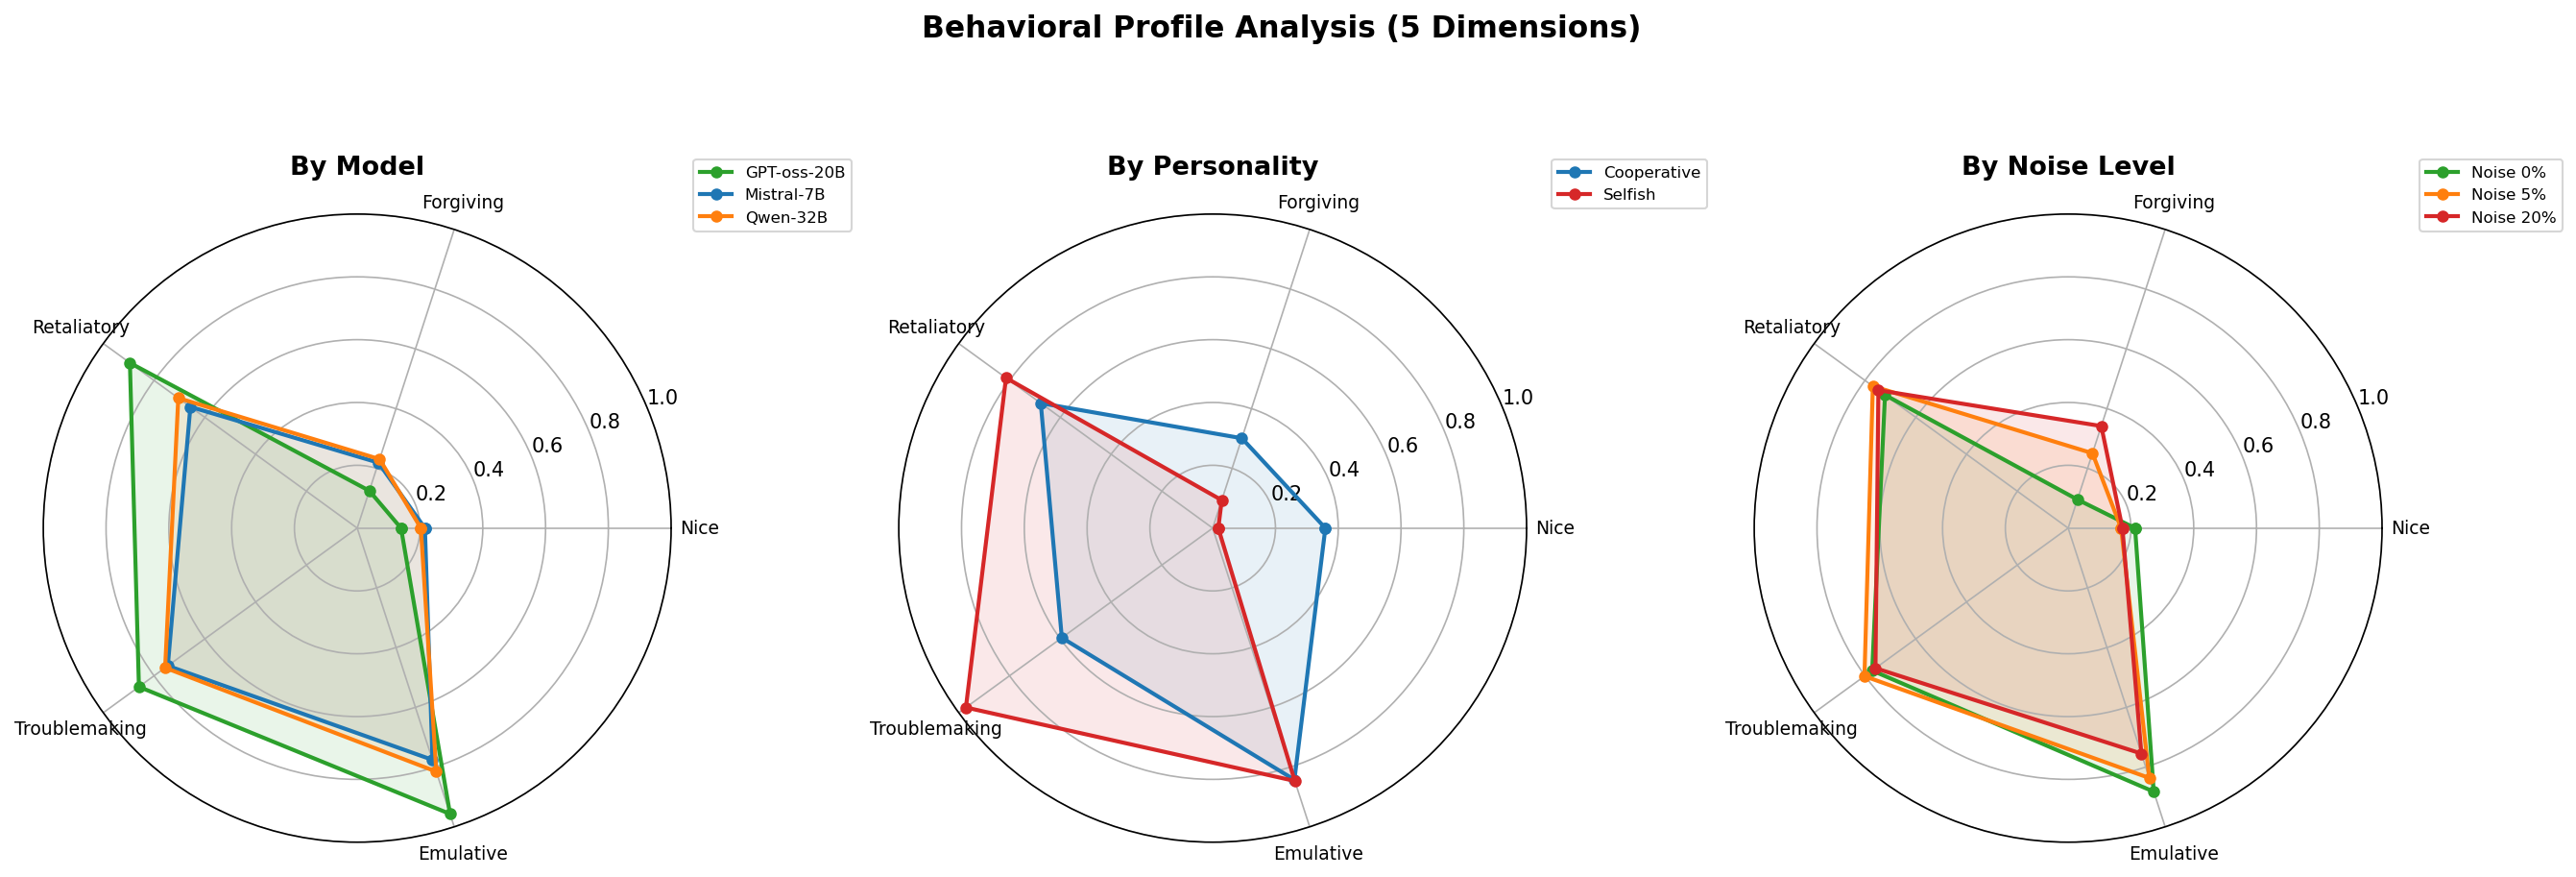


=== Mean Behavioral Profile by Model ===
              nice  forgiving  retaliatory  troublemaking  emulative
model                                                               
GPT-oss-20B  0.140      0.125        0.895          0.860      0.957
Mistral-7B   0.216      0.219        0.657          0.746      0.776
Qwen-32B     0.203      0.231        0.705          0.756      0.815

=== Mean Behavioral Profile by Model × Noise ===
                          nice  forgiving  retaliatory  troublemaking  emulative
model       noise_level                                                         
GPT-oss-20B 0            0.154      0.051        0.849          0.820      0.983
            5            0.125      0.199        0.941          0.899      0.931
Mistral-7B  0            0.235      0.156        0.633          0.745      0.770
            5            0.196      0.282        0.681          0.747      0.782
Qwen-32B    0            0.250      0.079        0.682          0.750      0.

In [5]:
# ============================================================================
# PART 5: BEHAVIORAL PROFILE ANALYSIS
# ============================================================================
from analysis.behavioral_profile import (
    compute_niceness, compute_forgiveness, compute_retaliation,
    compute_troublemaking, compute_emulation
)

def actions_to_binary(actions):
    """Convert action list to binary (1=Cooperate, 0=Defect)."""
    binary = []
    for a in actions:
        a_clean = a.strip().upper()
        if a_clean in ['C', 'COOPERATE', 'HOP TAC', 'COOPERER', 'COOPERARE', 'تعاون', '合作']:
            binary.append(1)
        else:
            binary.append(0)
    return binary

# Compute behavioral profiles for all games
behavioral_data = []
for _, row in df_games.iterrows():
    for agent_id in ['agent1', 'agent2']:
        strats = row[f'{agent_id}_strats']
        opp_id = 'agent2' if agent_id == 'agent1' else 'agent1'
        opp_strats = row[f'{opp_id}_strats']
        
        if len(strats) < 2 or len(opp_strats) < 2:
            continue
        
        main_h = actions_to_binary(strats)
        opp_h = actions_to_binary(opp_strats)
        
        behavioral_data.append({
            'model': row['model'],
            'llm_name': row['llm_name'],
            'noise_level': row['noise_level'],
            'language': row['language'],
            'personality': row[f'{agent_id}_personality_norm'],
            'matchup': row['matchup'],
            'nice': compute_niceness(main_h, opp_h),
            'forgiving': compute_forgiveness(main_h, opp_h),
            'retaliatory': compute_retaliation(main_h, opp_h),
            'troublemaking': compute_troublemaking(main_h, opp_h),
            'emulative': compute_emulation(main_h, opp_h),
            'coop_rate': np.mean(main_h)
        })

df_behavior = pd.DataFrame(behavioral_data)
print(f"Behavioral profiles computed for {len(df_behavior)} agent-game pairs")

# --- Figure 3: Radar Charts — Behavioral Profile by Model ---
from matplotlib.patches import FancyBboxPatch

dimensions = ['nice', 'forgiving', 'retaliatory', 'troublemaking', 'emulative']
dim_labels = ['Nice', 'Forgiving', 'Retaliatory', 'Troublemaking', 'Emulative']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw=dict(polar=True))

for idx, (group_col, group_title) in enumerate([
    ('model', 'By Model'),
    ('personality', 'By Personality'),
    ('noise_level', 'By Noise Level')
]):
    ax = axes[idx]
    groups = sorted(df_behavior[group_col].unique())
    
    angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
    angles += angles[:1]
    
    colors_map = MODEL_COLORS if group_col == 'llm_name' else \
                 NOISE_COLORS if group_col == 'noise_level' else \
                 PERSONALITY_COLORS
    
    for g in groups:
        subset = df_behavior[df_behavior[group_col] == g]
        values = [subset[d].mean() for d in dimensions]
        values += values[:1]
        
        label = MODEL_SHORT.get(g, str(g))
        if group_col == 'noise_level':
            label = f"Noise {g}%"
            color = NOISE_COLORS.get(g, '#333')
        elif group_col == 'personality':
            color = PERSONALITY_COLORS.get(g, '#333')
            label = g.capitalize()
        else:
            color = list(MODEL_COLORS.values())[list(MODEL_SHORT.values()).index(g)] if g in MODEL_SHORT.values() else '#333'
        
        ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color, markersize=5)
        ax.fill(angles, values, alpha=0.1, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(dim_labels, fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(group_title, fontsize=13, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.suptitle('Behavioral Profile Analysis (5 Dimensions)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_behavioral_radar_charts.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig3_behavioral_radar_charts.png', bbox_inches='tight')
plt.show()

# --- Print Behavioral Profile Table ---
print("\n=== Mean Behavioral Profile by Model ===")
bp_model = df_behavior.groupby('model')[dimensions].mean()
print(bp_model.round(3).to_string())

print("\n=== Mean Behavioral Profile by Model × Noise ===")
bp_mn = df_behavior.groupby(['model', 'noise_level'])[dimensions].mean()
print(bp_mn.round(3).to_string())

## Part 6: SFEM — Strategy Frequency Estimation Method
### From Romero & Rosokha (2018), adapted from ICWSM'25

SFEM decomposes each LLM's gameplay into a **probabilistic mixture** of 7 canonical strategies:

| Strategy | Label | Description |
|---|---|---|
| Always Cooperate | AC | Always plays C |
| Always Defect | AD | Always plays D |
| Tit-for-Tat | TFT | Copies opponent's last move, starts with C |
| Suspicious TFT | STFT | Like TFT but starts with D |
| Grim Trigger | GRIM | Cooperates until first defection, then always D |
| Win-Stay Lose-Shift | WSLS | Repeats action if same as opponent, else switches |
| Random | RND | 50/50 random |

Uses Maximum Likelihood Estimation with SLSQP optimization (50 random restarts).

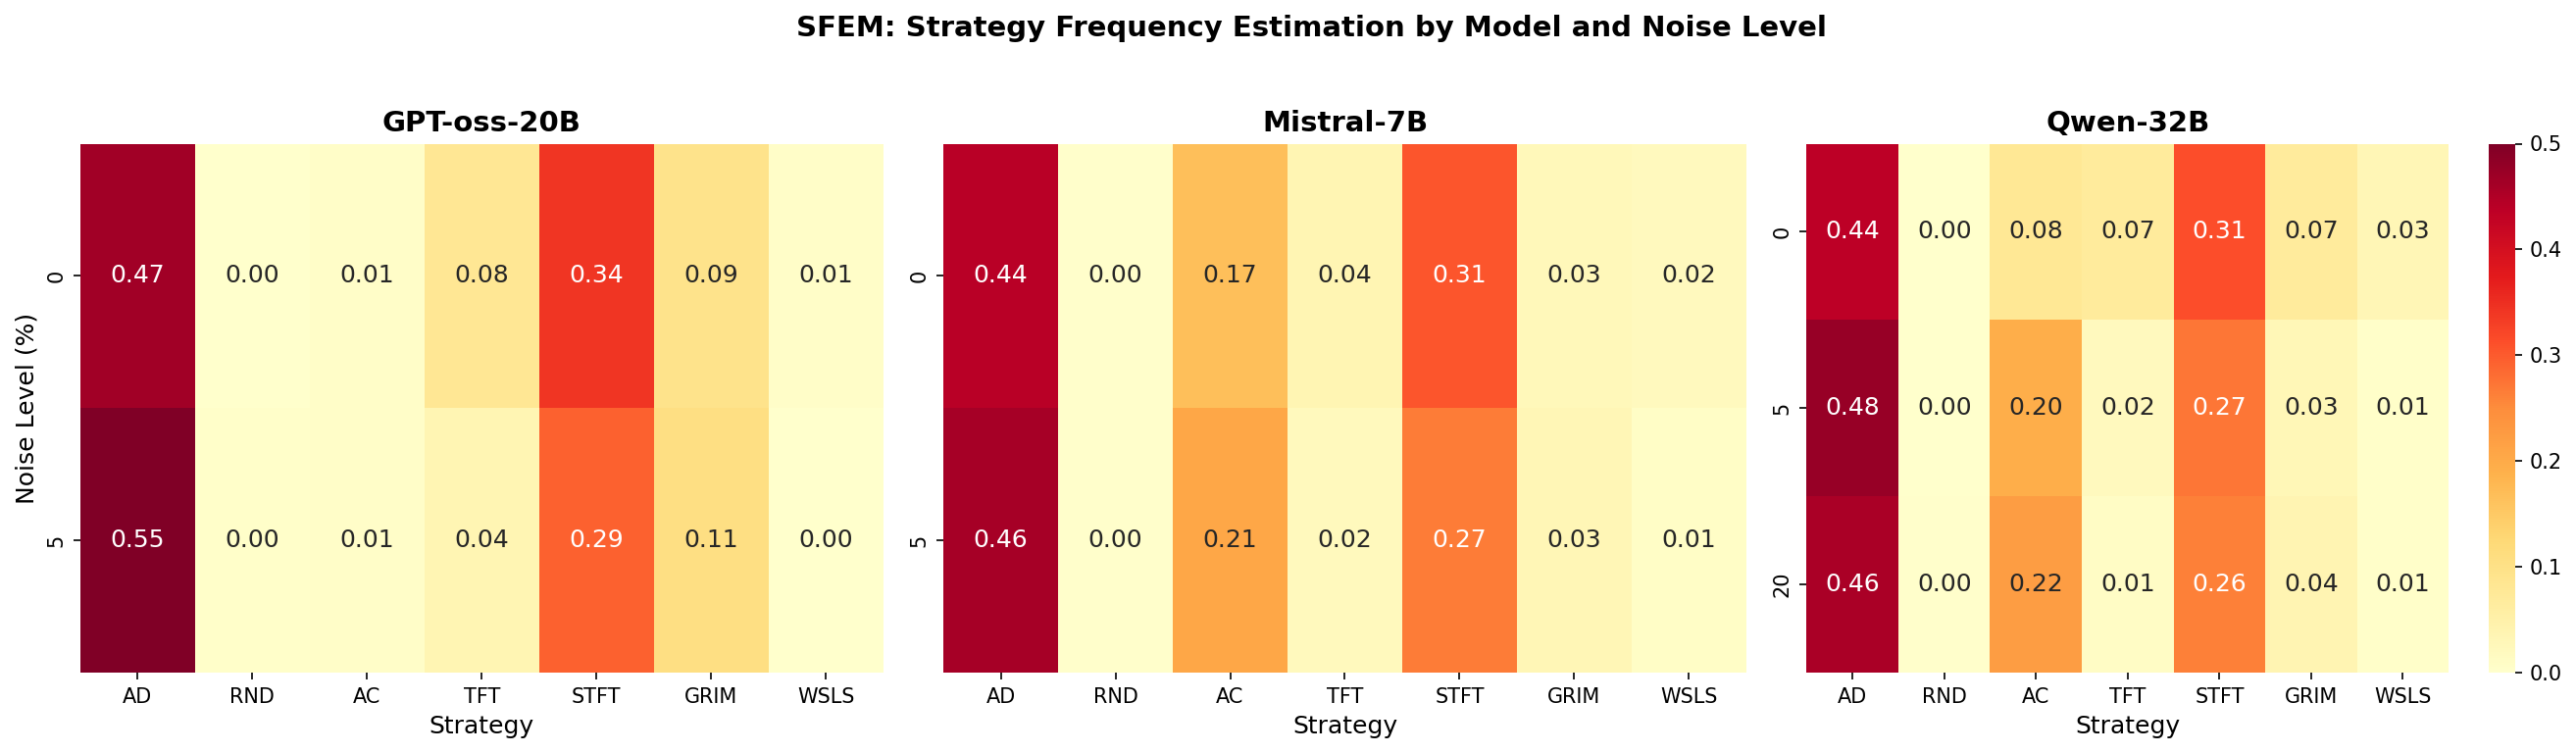


=== SFEM Results ===
                            AD    RND     AC    TFT   STFT   GRIM   WSLS
model       noise_level                                                 
Mistral-7B  0            0.441  0.002  0.166  0.037  0.306  0.026  0.021
            5            0.461  0.002  0.206  0.023  0.266  0.033  0.009
Qwen-32B    0            0.436  0.000  0.078  0.070  0.314  0.070  0.032
            5            0.476  0.000  0.195  0.021  0.272  0.031  0.005
            20           0.455  0.002  0.224  0.012  0.263  0.038  0.005
GPT-oss-20B 0            0.466  0.000  0.007  0.082  0.344  0.095  0.007
            5            0.554  0.004  0.006  0.035  0.294  0.106  0.000


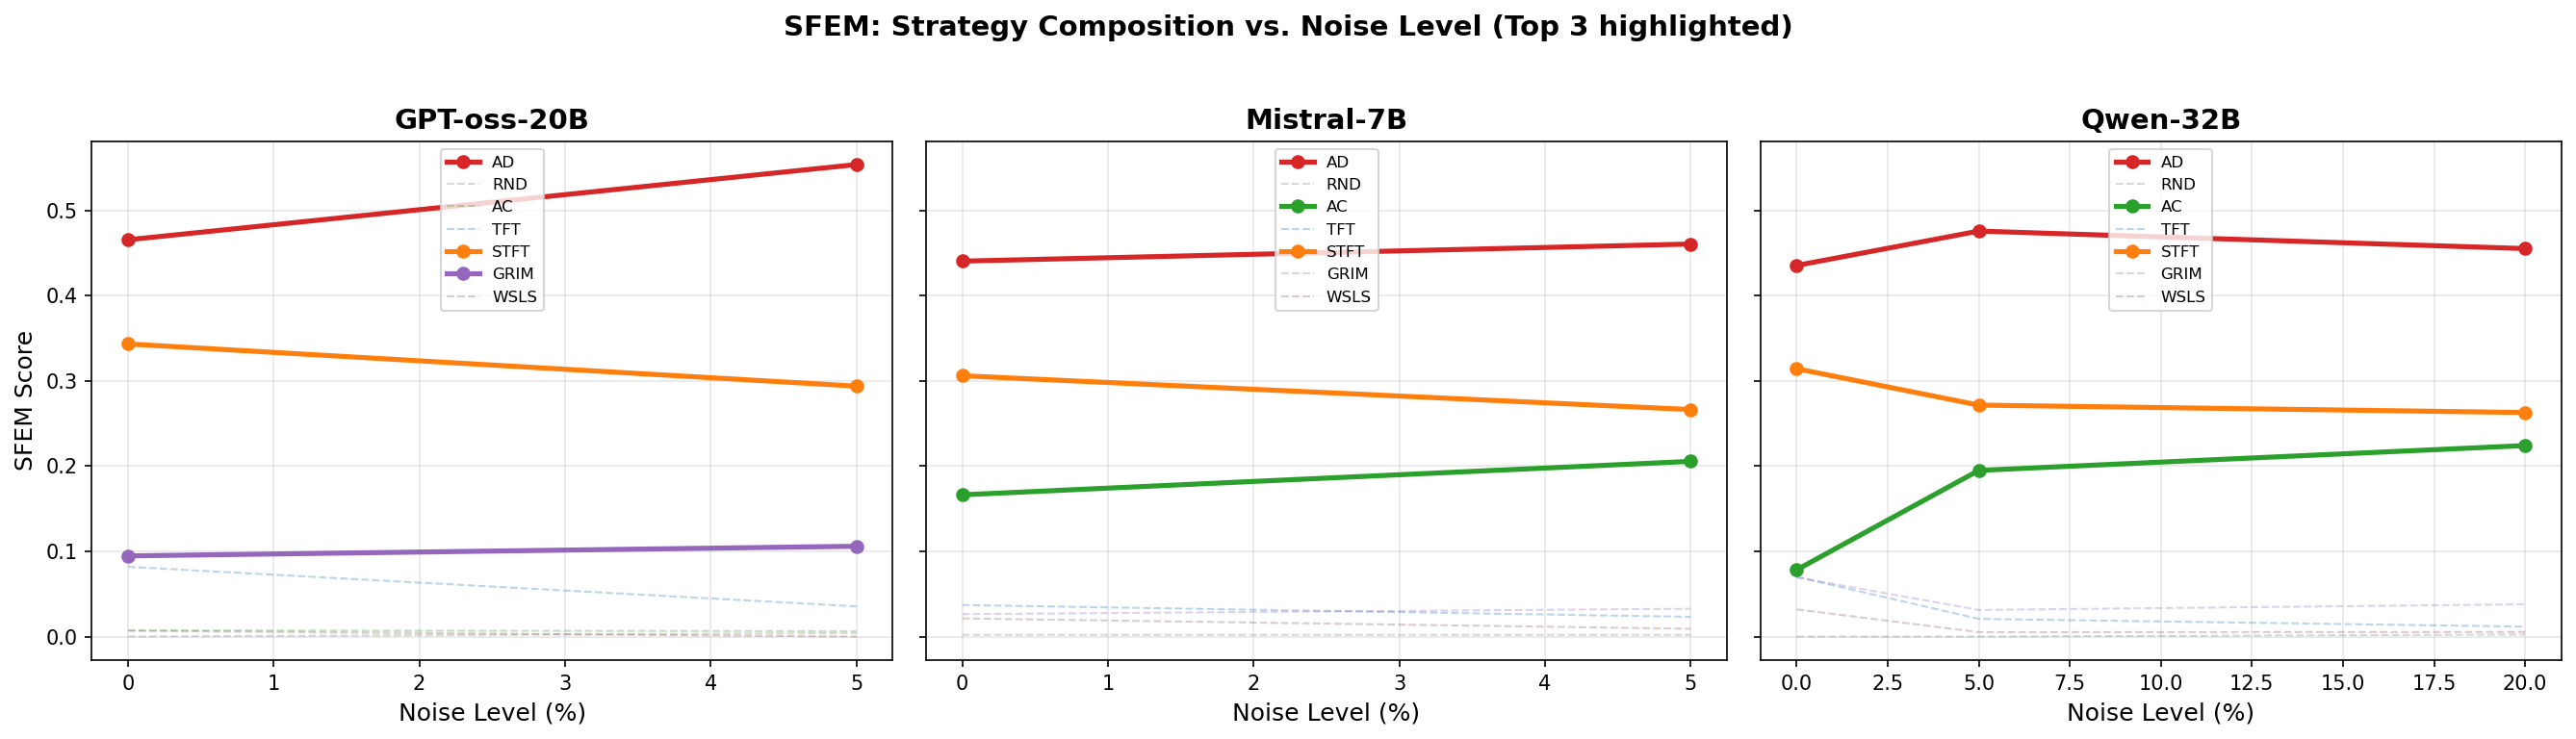

In [6]:
# ============================================================================
# PART 6: SFEM ANALYSIS
# ============================================================================
from analysis.sfem_computation import compute_sfem, get_default_strategies

# Prepare game histories for SFEM
def prepare_sfem_histories(df, agent_col='agent1'):
    """Convert game DataFrame rows into SFEM-compatible histories."""
    histories = []
    opp_col = 'agent2' if agent_col == 'agent1' else 'agent1'
    for _, row in df.iterrows():
        main_h = actions_to_binary(row[f'{agent_col}_strats'])
        opp_h = actions_to_binary(row[f'{opp_col}_strats'])
        if len(main_h) >= 5 and len(opp_h) >= 5:
            histories.append({'main_history': main_h, 'opponent_history': opp_h})
    return histories

# Compute SFEM for each Model × Noise Level
sfem_results = []
strategy_labels = None

for model in sorted(df_games['llm_name'].unique()):
    for noise in sorted(df_games['noise_level'].unique()):
        subset = df_games[(df_games['llm_name'] == model) & (df_games['noise_level'] == noise)]
        if len(subset) == 0:
            continue
        
        # Get histories from both agents
        histories = prepare_sfem_histories(subset, 'agent1') + prepare_sfem_histories(subset, 'agent2')
        
        if len(histories) > 0:
            scores, labels = compute_sfem(histories, n_restarts=30)
            strategy_labels = labels
            
            result = {
                'model': MODEL_SHORT[model],
                'llm_name': model,
                'noise_level': noise,
                'n_games': len(histories)
            }
            for label, score in zip(labels, scores):
                result[label] = score
            sfem_results.append(result)

df_sfem = pd.DataFrame(sfem_results)

# --- Figure 4: SFEM Heatmap by Model × Noise ---
if strategy_labels and len(df_sfem) > 0:
    fig, axes = plt.subplots(1, len(df_games['llm_name'].unique()), figsize=(18, 5))
    
    for idx, model in enumerate(sorted(df_sfem['model'].unique())):
        ax = axes[idx] if len(axes.shape) > 0 else axes
        model_sfem = df_sfem[df_sfem['model'] == model].set_index('noise_level')[strategy_labels]
        
        sns.heatmap(model_sfem, annot=True, fmt='.2f', cmap='YlOrRd', 
                   vmin=0, vmax=0.5, ax=ax, cbar=idx == len(df_sfem['model'].unique())-1)
        ax.set_title(f'{model}', fontweight='bold')
        ax.set_ylabel('Noise Level (%)' if idx == 0 else '')
        ax.set_xlabel('Strategy')
    
    plt.suptitle('SFEM: Strategy Frequency Estimation by Model and Noise Level',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/fig4_sfem_heatmap.pdf', bbox_inches='tight')
    plt.savefig(f'{FIGURES_DIR}/fig4_sfem_heatmap.png', bbox_inches='tight')
    plt.show()

# --- Print SFEM Summary Table ---
print("\n=== SFEM Results ===")
if len(df_sfem) > 0:
    print(df_sfem.set_index(['model', 'noise_level'])[strategy_labels].round(3).to_string())

# --- Figure 5: SFEM Line Plot (Top strategies across noise) ---
if strategy_labels and len(df_sfem) > 0:
    fig, axes = plt.subplots(1, len(df_sfem['model'].unique()), figsize=(18, 5), sharey=True)
    
    for idx, model in enumerate(sorted(df_sfem['model'].unique())):
        ax = axes[idx]
        model_sfem = df_sfem[df_sfem['model'] == model]
        
        # Find top 3 strategies by max score
        max_scores = {s: model_sfem[s].max() for s in strategy_labels}
        top3 = sorted(max_scores, key=max_scores.get, reverse=True)[:3]
        
        strat_colors = {'AD':'#d62728', 'AC':'#2ca02c', 'TFT':'#1f77b4', 
                        'STFT':'#ff7f0e', 'GRIM':'#9467bd', 'WSLS':'#8c564b', 'RND':'#7f7f7f'}
        
        for s in strategy_labels:
            style = '-o' if s in top3 else '--'
            alpha = 1.0 if s in top3 else 0.3
            lw = 2.5 if s in top3 else 1
            ax.plot(model_sfem['noise_level'], model_sfem[s], style,
                   label=s, color=strat_colors.get(s, '#333'), alpha=alpha, linewidth=lw, markersize=6)
        
        ax.set_title(model, fontweight='bold')
        ax.set_xlabel('Noise Level (%)')
        ax.set_ylabel('SFEM Score' if idx == 0 else '')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    
    plt.suptitle('SFEM: Strategy Composition vs. Noise Level (Top 3 highlighted)',
                fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/fig5_sfem_line_plot.pdf', bbox_inches='tight')
    plt.savefig(f'{FIGURES_DIR}/fig5_sfem_line_plot.png', bbox_inches='tight')
    plt.show()

## Part 7: Cooperation Dynamics — Round-by-Round Analysis
### How does cooperation evolve over 30 rounds?

Key questions:
- Do LLMs start cooperatively and become defective (like humans)?
- Does noise disrupt the cooperation trajectory?
- Is there a "learning phase" vs. "steady state"?

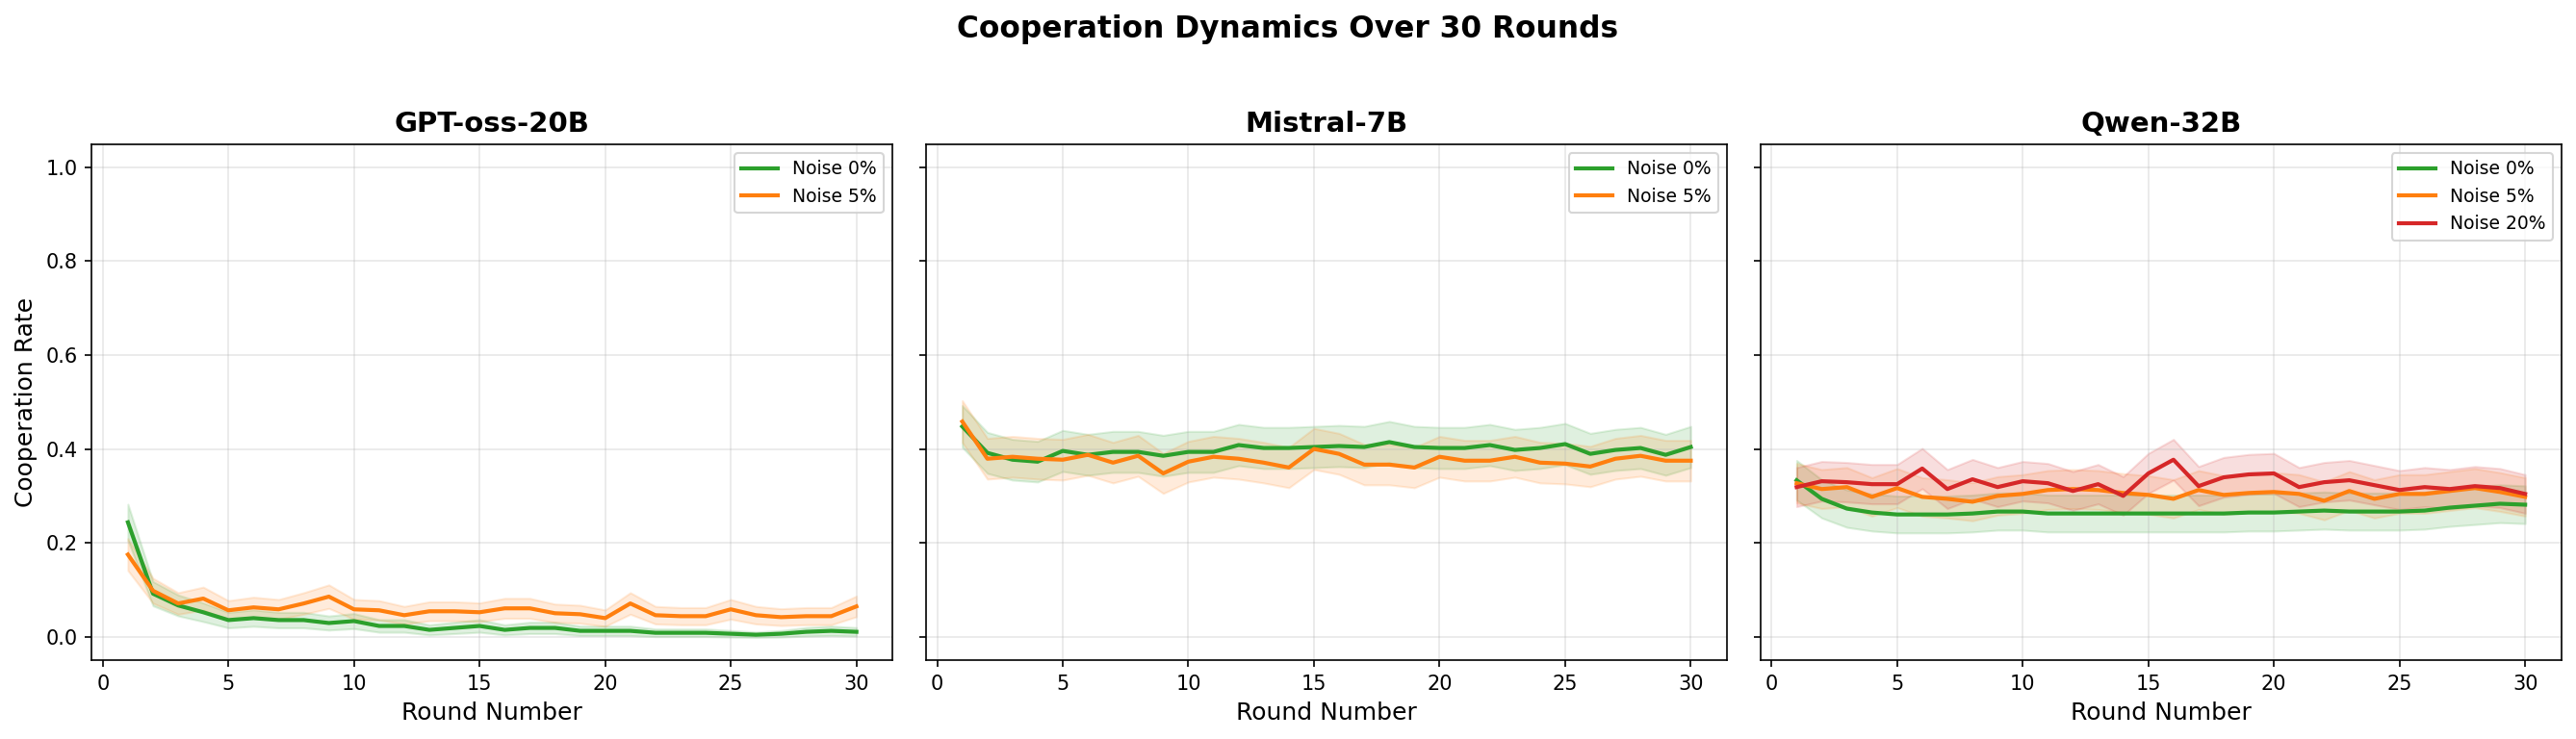

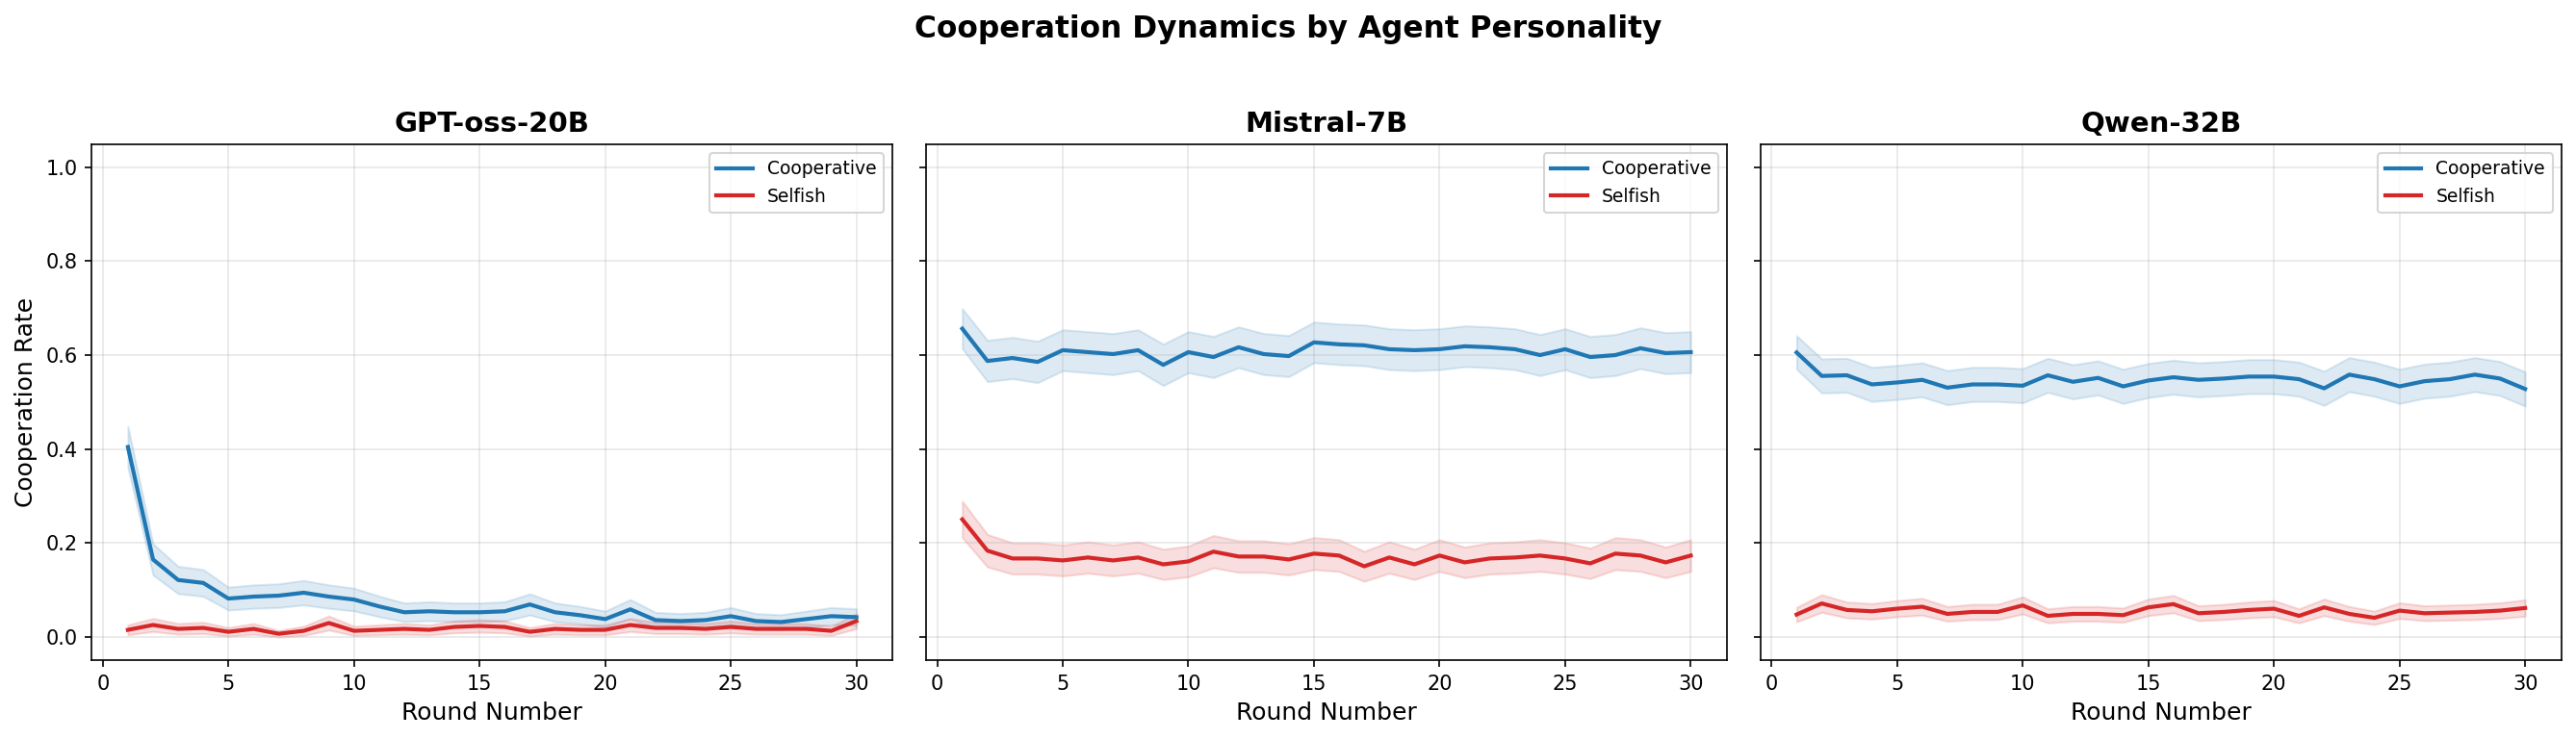


=== Steady-State vs Early-Game Cooperation ===
 GPT-oss-20B | Early(R1-10): 0.074 | Late(R21-30): 0.029 | Delta: -0.044
  Mistral-7B | Early(R1-10): 0.389 | Late(R21-30): 0.388 | Delta: -0.001
    Qwen-32B | Early(R1-10): 0.303 | Late(R21-30): 0.298 | Delta: -0.004


In [7]:
# ============================================================================
# PART 7: COOPERATION DYNAMICS (ROUND-BY-ROUND)
# ============================================================================

# Normalize round-level strategies to binary cooperation
def is_cooperate(strategy):
    if isinstance(strategy, str):
        s = strategy.strip().lower()
        return s in ['cooperate', 'c', 'hop tac', 'cooperer', 'cooperare', 'تعاون', '合作']
    return False

df_rounds['is_coop'] = df_rounds['final_strategy'].apply(lambda x: 1 if is_cooperate(x) else 0)
df_rounds['model'] = df_rounds['llm_name'].map(MODEL_SHORT)

if 'agent_personality' in df_rounds.columns:
    df_rounds['personality_norm'] = df_rounds['agent_personality'].apply(normalize_personality)

# --- Figure 6: Round-by-Round Cooperation by Model ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, model in enumerate(sorted(df_rounds['model'].dropna().unique())):
    ax = axes[idx]
    model_rounds = df_rounds[df_rounds['model'] == model]
    
    for noise in sorted(model_rounds['noise_level'].unique()):
        noise_data = model_rounds[model_rounds['noise_level'] == noise]
        round_coop = noise_data.groupby('round_number')['is_coop'].agg(['mean', 'std', 'count'])
        round_coop['ci'] = 1.96 * round_coop['std'] / np.sqrt(round_coop['count'])
        
        color = NOISE_COLORS.get(noise, '#333')
        ax.plot(round_coop.index, round_coop['mean'], '-', 
               label=f'Noise {noise}%', color=color, linewidth=2)
        ax.fill_between(round_coop.index, 
                       round_coop['mean'] - round_coop['ci'],
                       round_coop['mean'] + round_coop['ci'],
                       alpha=0.15, color=color)
    
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('Round Number')
    ax.set_ylabel('Cooperation Rate' if idx == 0 else '')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cooperation Dynamics Over 30 Rounds', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig6_cooperation_dynamics.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig6_cooperation_dynamics.png', bbox_inches='tight')
plt.show()

# --- Figure 7: Round-by-Round by Personality ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, model in enumerate(sorted(df_rounds['model'].dropna().unique())):
    ax = axes[idx]
    model_rounds = df_rounds[df_rounds['model'] == model]
    
    for pers in ['cooperative', 'selfish']:
        pers_data = model_rounds[model_rounds['personality_norm'] == pers]
        round_coop = pers_data.groupby('round_number')['is_coop'].agg(['mean', 'std', 'count'])
        round_coop['ci'] = 1.96 * round_coop['std'] / np.sqrt(round_coop['count'])
        
        color = PERSONALITY_COLORS.get(pers, '#333')
        ax.plot(round_coop.index, round_coop['mean'], '-', 
               label=pers.capitalize(), color=color, linewidth=2)
        ax.fill_between(round_coop.index, 
                       round_coop['mean'] - round_coop['ci'],
                       round_coop['mean'] + round_coop['ci'],
                       alpha=0.15, color=color)
    
    ax.set_title(f'{model}', fontweight='bold')
    ax.set_xlabel('Round Number')
    ax.set_ylabel('Cooperation Rate' if idx == 0 else '')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Cooperation Dynamics by Agent Personality', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig7_cooperation_by_personality.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig7_cooperation_by_personality.png', bbox_inches='tight')
plt.show()

# --- Steady-State Analysis (last 10 rounds vs first 10) ---
print("\n=== Steady-State vs Early-Game Cooperation ===")
for model in sorted(df_rounds['model'].dropna().unique()):
    m_data = df_rounds[df_rounds['model'] == model]
    early = m_data[m_data['round_number'] <= 10]['is_coop'].mean()
    late = m_data[m_data['round_number'] > 20]['is_coop'].mean()
    delta = late - early
    print(f"{model:>12s} | Early(R1-10): {early:.3f} | Late(R21-30): {late:.3f} | Delta: {delta:+.3f}")

## Part 8: Noise Impact — Intended vs. Actual Cooperation
### The Trembling Hand in Action

When noise is applied, agents' *intended* actions may differ from *actual* (executed) actions. 
This creates a natural experiment to study:
- How "clean" is agent reasoning when noise confounds outcomes?
- Does noise-induced cooperation lead to better payoffs?
- Can agents detect and attribute noise correctly?

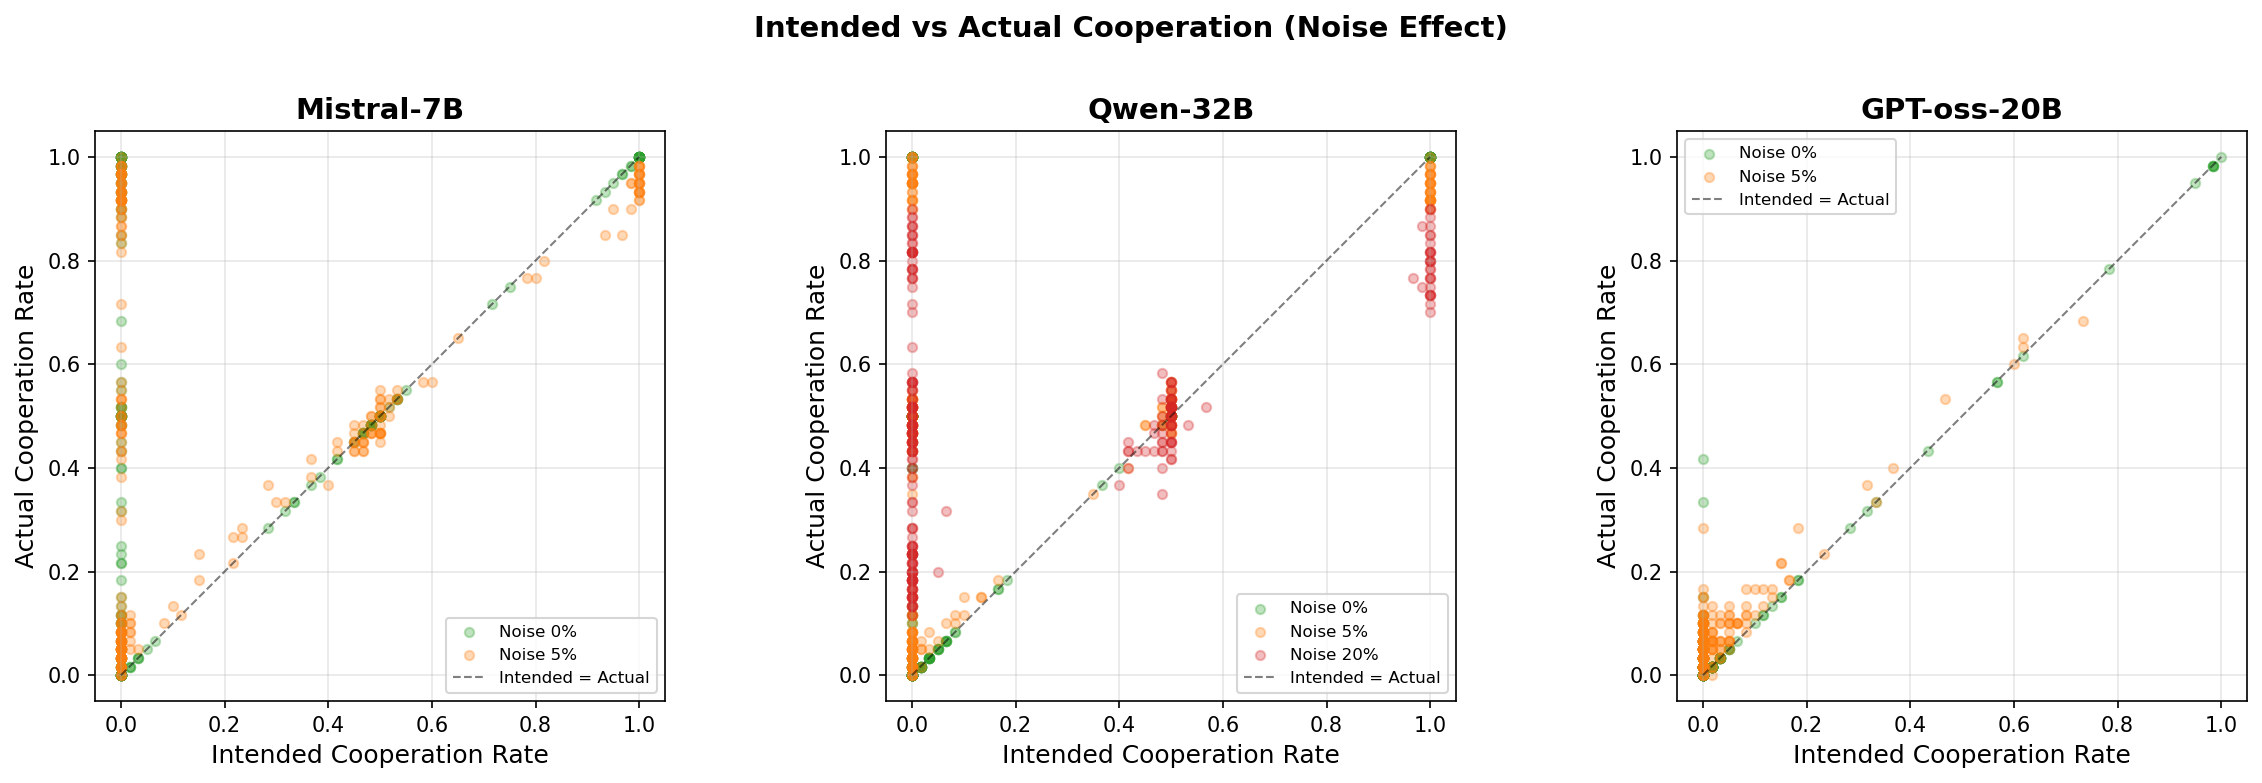

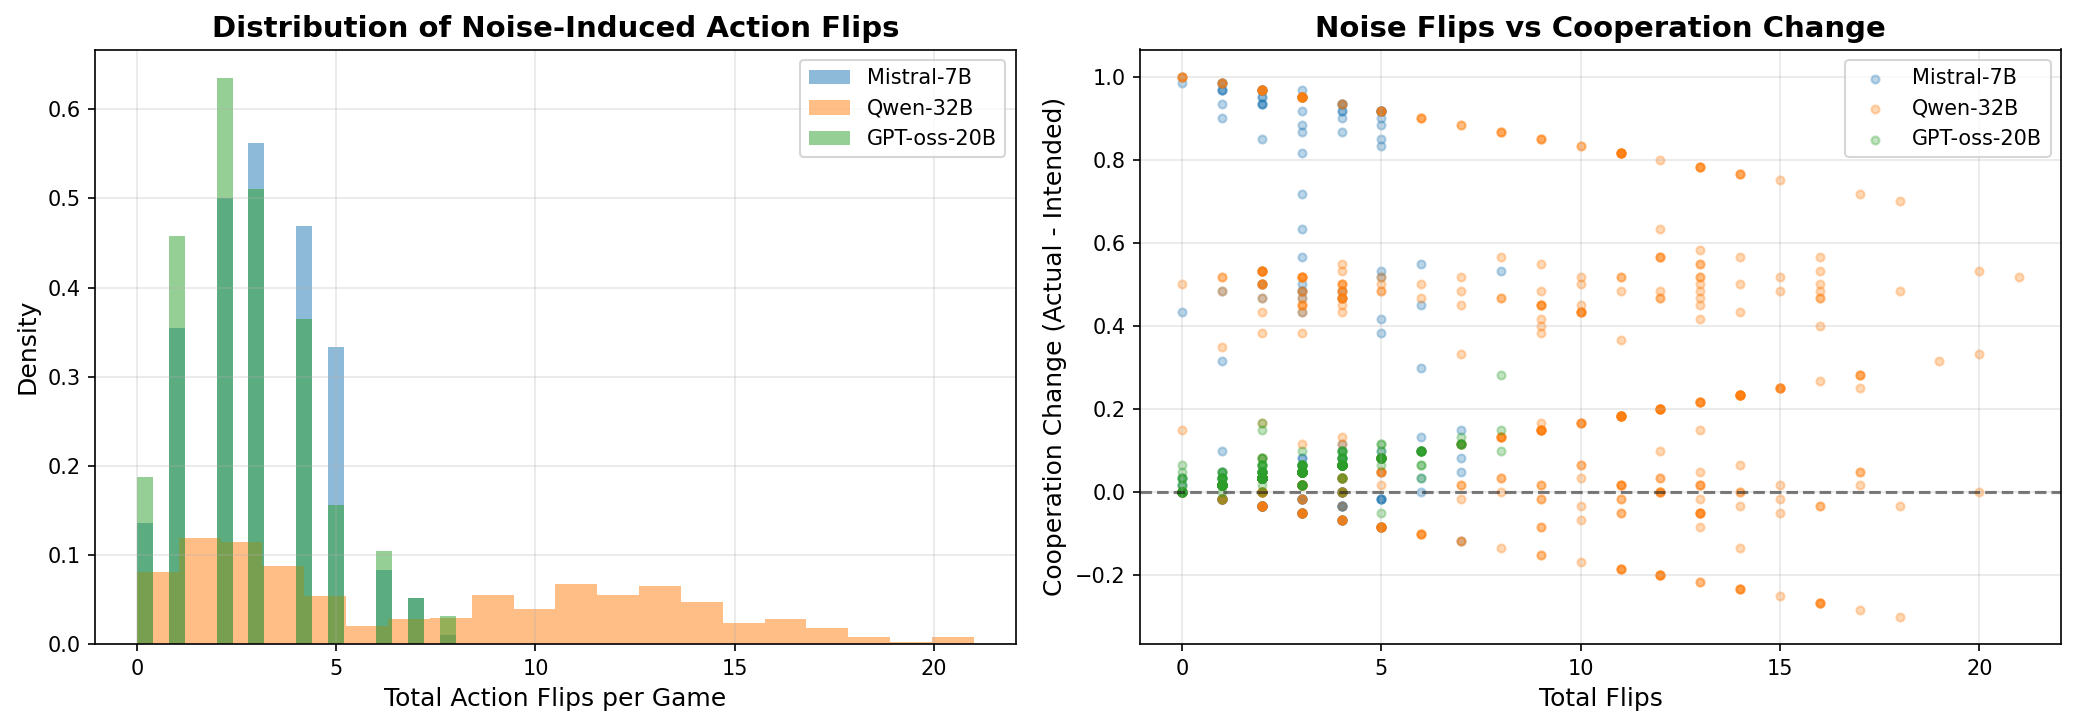


=== Noise Impact Summary ===
  Mistral-7B | Noise= 0% | Intended: 0.237 | Actual: 0.515 | Delta: +0.277 | Avg Flips: 0.0
  Mistral-7B | Noise= 5% | Intended: 0.231 | Actual: 0.469 | Delta: +0.238 | Avg Flips: 3.0
  Mistral-7B | Noise=20% | Intended: nan | Actual: nan | Delta: +nan | Avg Flips: nan
    Qwen-32B | Noise= 0% | Intended: 0.179 | Actual: 0.397 | Delta: +0.218 | Avg Flips: 0.0
    Qwen-32B | Noise= 5% | Intended: 0.221 | Actual: 0.459 | Delta: +0.238 | Avg Flips: 2.9
    Qwen-32B | Noise=20% | Intended: 0.243 | Actual: 0.491 | Delta: +0.248 | Avg Flips: 11.9
 GPT-oss-20B | Noise= 0% | Intended: 0.051 | Actual: 0.065 | Delta: +0.013 | Avg Flips: 0.0
 GPT-oss-20B | Noise= 5% | Intended: 0.033 | Actual: 0.082 | Delta: +0.050 | Avg Flips: 2.7
 GPT-oss-20B | Noise=20% | Intended: nan | Actual: nan | Delta: +nan | Avg Flips: nan


In [8]:
# ============================================================================
# PART 8: NOISE IMPACT — INTENDED vs ACTUAL COOPERATION
# ============================================================================

# Compute intended cooperation rate from intended strategies
def intended_coop_rate(intended_strats):
    if not isinstance(intended_strats, list) or len(intended_strats) == 0:
        return np.nan
    binary = actions_to_binary(intended_strats)
    return np.mean(binary)

df_games['agent1_intended_coop'] = df_games['agent1_intended'].apply(intended_coop_rate)
df_games['agent2_intended_coop'] = df_games['agent2_intended'].apply(intended_coop_rate)
df_games['avg_intended_coop'] = (df_games['agent1_intended_coop'] + df_games['agent2_intended_coop']) / 2

# --- Figure 8: Intended vs Actual Cooperation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[idx]
    m_data = df_games[df_games['llm_name'] == model]
    
    for noise in sorted(m_data['noise_level'].unique()):
        n_data = m_data[m_data['noise_level'] == noise]
        color = NOISE_COLORS.get(noise, '#333')
        
        ax.scatter(n_data['avg_intended_coop'], n_data['avg_coop_rate'],
                  alpha=0.3, s=20, color=color, label=f'Noise {noise}%')
    
    # Add diagonal reference
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, linewidth=1, label='Intended = Actual')
    ax.set_xlabel('Intended Cooperation Rate')
    ax.set_ylabel('Actual Cooperation Rate')
    ax.set_title(MODEL_SHORT[model], fontweight='bold')
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=8)
    ax.set_aspect('equal')
    ax.grid(alpha=0.3)

plt.suptitle('Intended vs Actual Cooperation (Noise Effect)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig8_intended_vs_actual.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig8_intended_vs_actual.png', bbox_inches='tight')
plt.show()

# --- Figure 9: Flip Count Analysis ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 9a: Distribution of flips
ax = axes[0]
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[(df_games['llm_name'] == model) & (df_games['noise_level'] > 0)]
    total_flips = m_data['agent1_flipped_count'].fillna(0) + m_data['agent2_flipped_count'].fillna(0)
    ax.hist(total_flips, bins=20, alpha=0.5, label=MODEL_SHORT[model], density=True)

ax.set_xlabel('Total Action Flips per Game')
ax.set_ylabel('Density')
ax.set_title('Distribution of Noise-Induced Action Flips', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 9b: Flips vs Cooperation Change
ax = axes[1]
noisy_games = df_games[df_games['noise_level'] > 0].copy()
noisy_games['total_flips'] = noisy_games['agent1_flipped_count'].fillna(0) + noisy_games['agent2_flipped_count'].fillna(0)
noisy_games['coop_diff'] = noisy_games['avg_coop_rate'] - noisy_games['avg_intended_coop']

for model in sorted(noisy_games['llm_name'].unique()):
    m_data = noisy_games[noisy_games['llm_name'] == model]
    ax.scatter(m_data['total_flips'], m_data['coop_diff'], alpha=0.3, s=15, label=MODEL_SHORT[model])

ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
ax.set_xlabel('Total Flips')
ax.set_ylabel('Cooperation Change (Actual - Intended)')
ax.set_title('Noise Flips vs Cooperation Change', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig9_noise_flip_analysis.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig9_noise_flip_analysis.png', bbox_inches='tight')
plt.show()

# --- Print Noise Impact Summary ---
print("\n=== Noise Impact Summary ===")
for model in sorted(df_games['llm_name'].unique()):
    for noise in sorted(df_games['noise_level'].unique()):
        subset = df_games[(df_games['llm_name'] == model) & (df_games['noise_level'] == noise)]
        intended = subset['avg_intended_coop'].mean()
        actual = subset['avg_coop_rate'].mean()
        flips = (subset['agent1_flipped_count'].fillna(0) + subset['agent2_flipped_count'].fillna(0)).mean()
        print(f"{MODEL_SHORT[model]:>12s} | Noise={noise:>2d}% | Intended: {intended:.3f} | Actual: {actual:.3f} | Delta: {actual-intended:+.3f} | Avg Flips: {flips:.1f}")

## Part 9: Multilingual Analysis — Cross-Language Behavioral Consistency
### Novel contribution: 6-language comparison (EN, FR, AR, CN, VN, IT)

Key question: **Is LLM game-theoretic behavior language-dependent?**

This extends ICWSM'25 (English-only) to probe whether:
- Cooperation rates differ across languages
- Strategic profiles are consistent across cultures/languages
- Personality prompts are equally effective in all languages

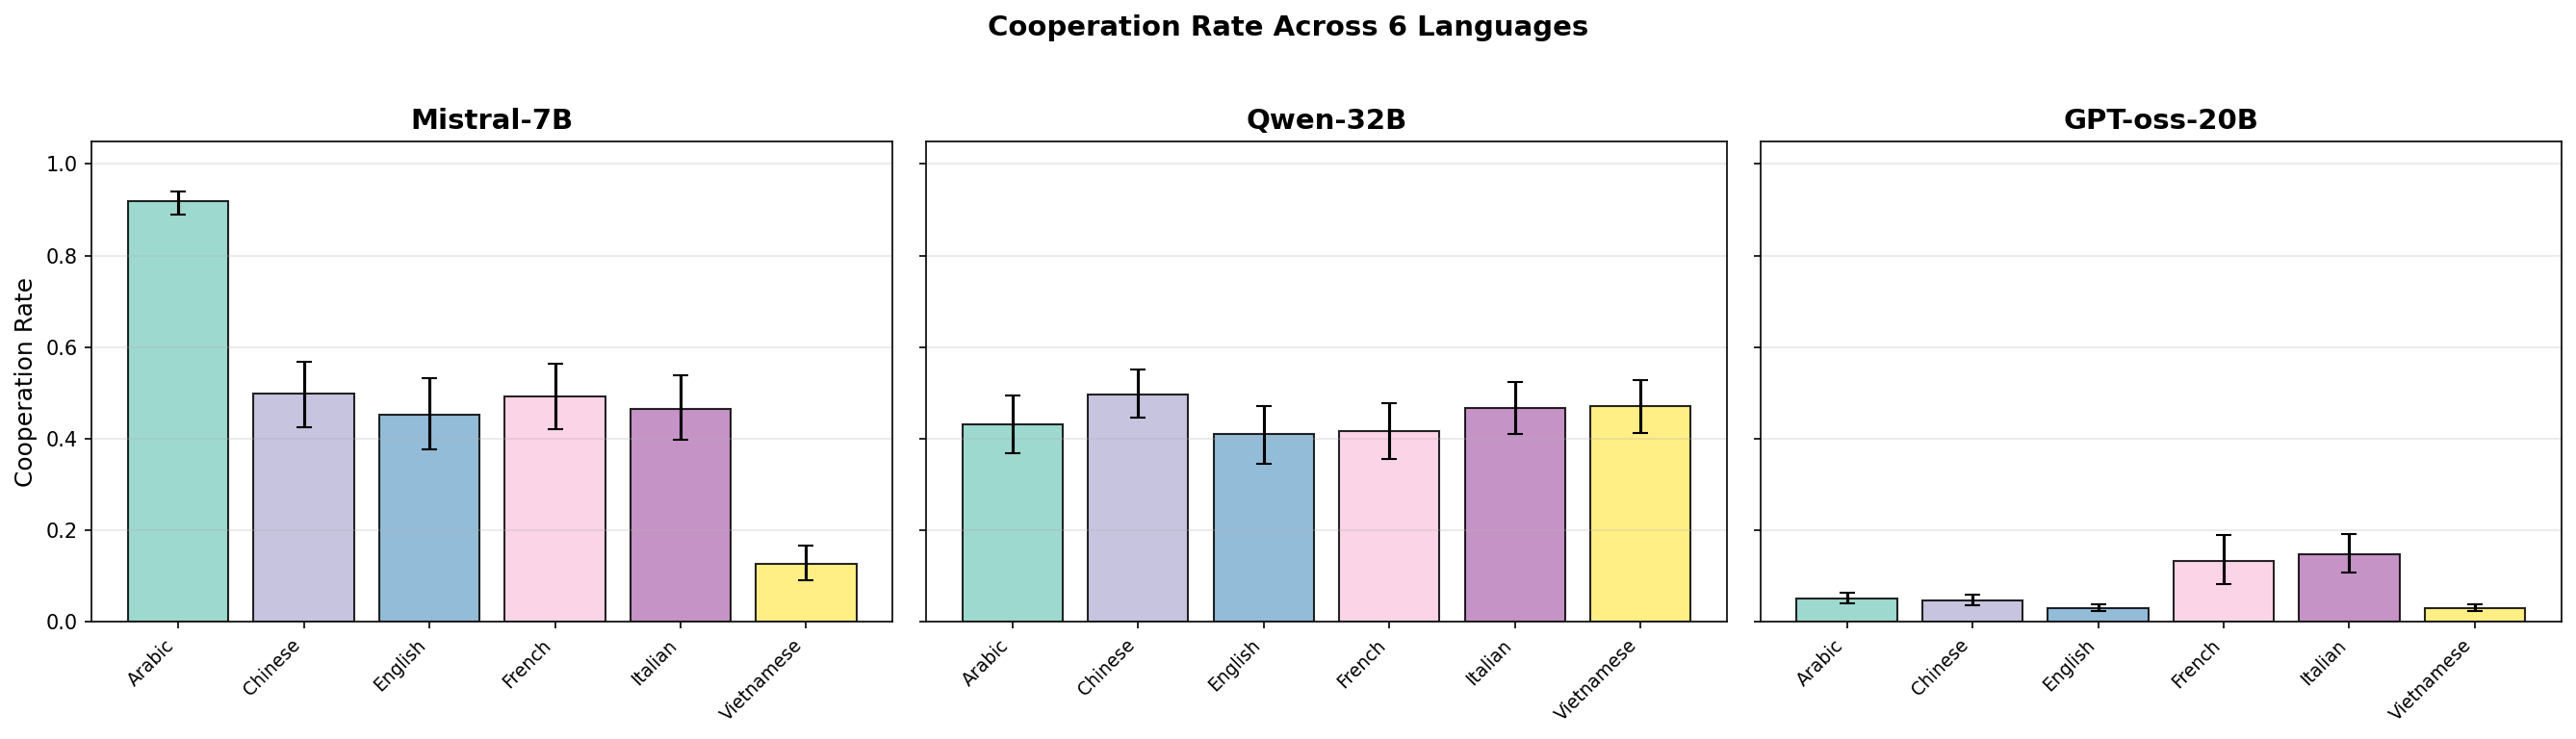

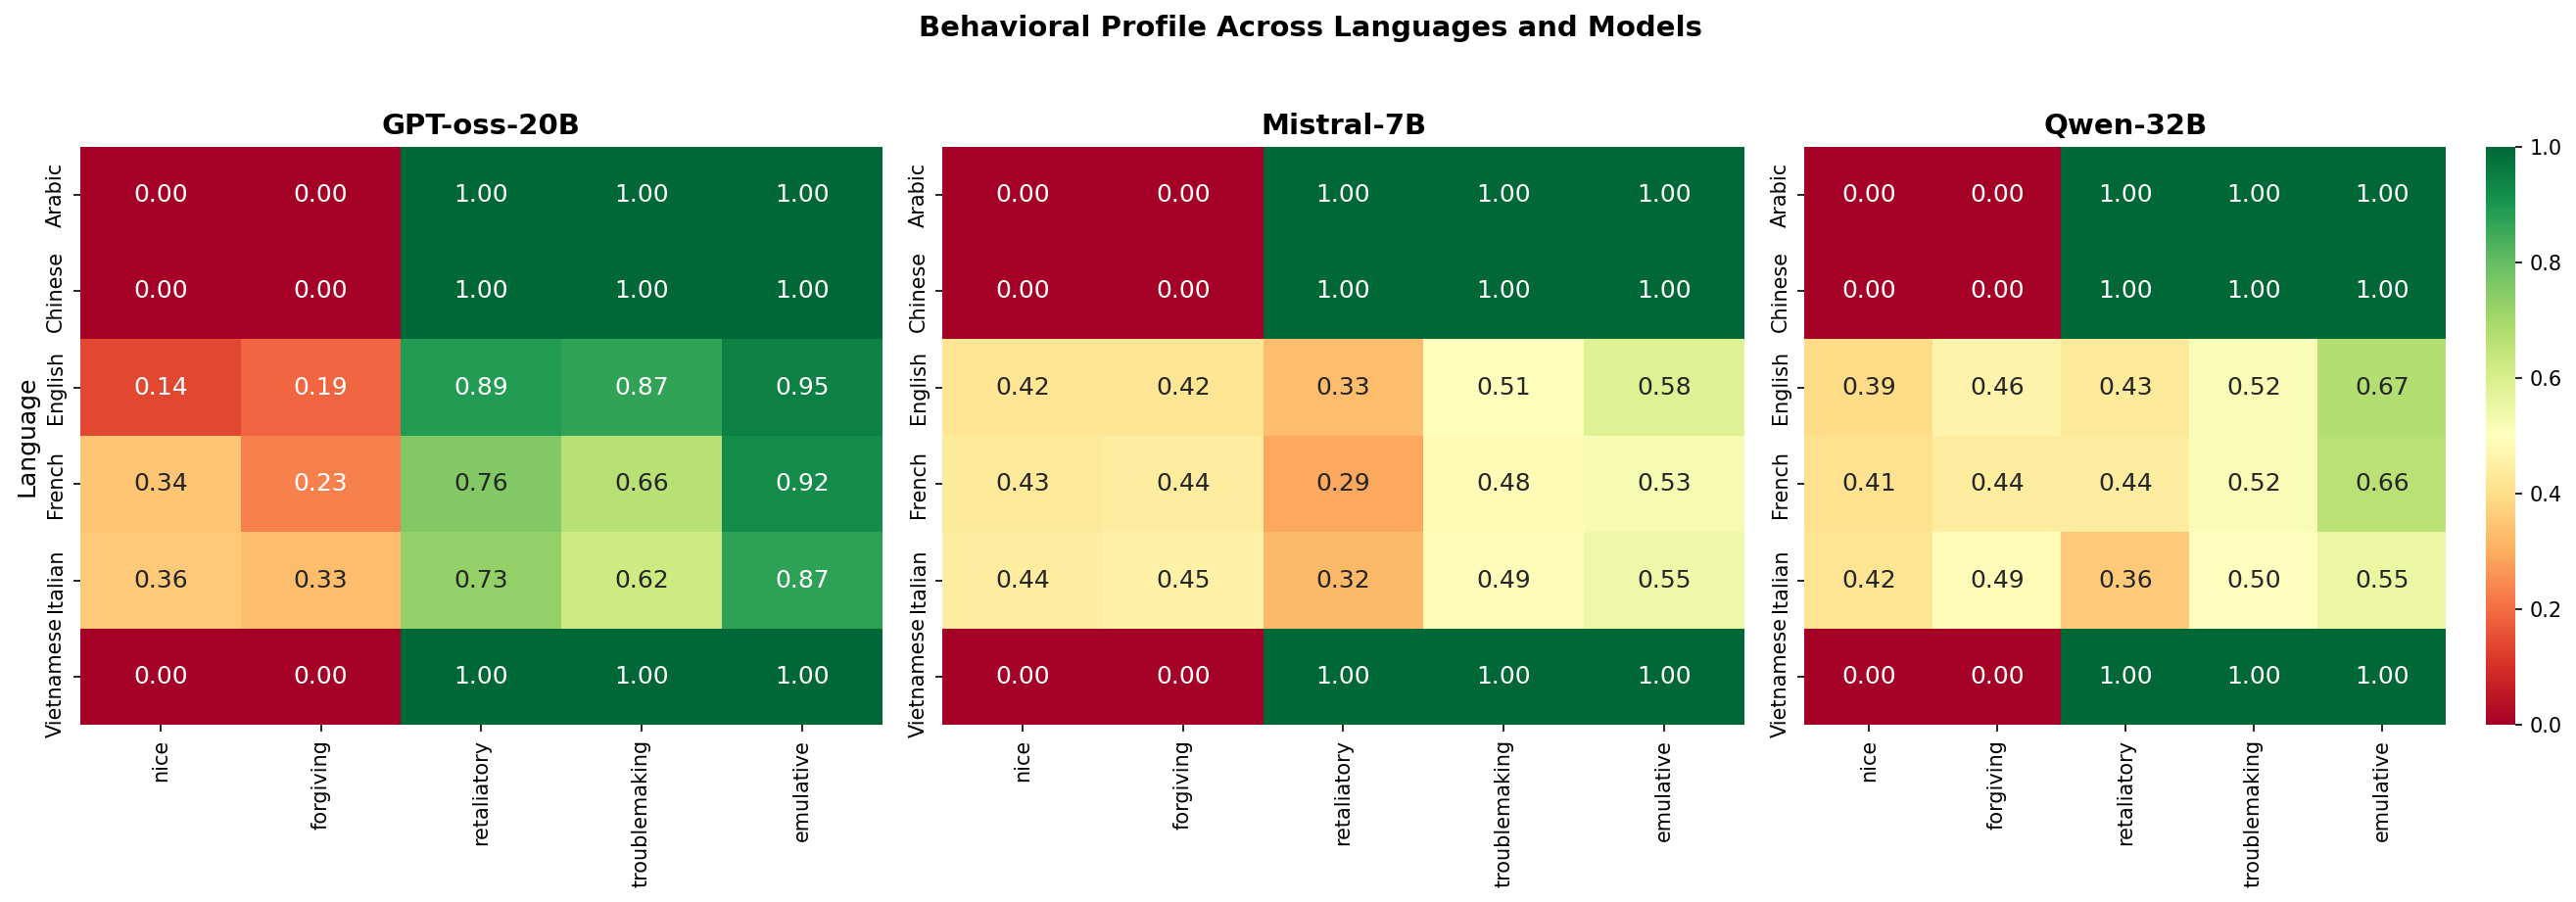


=== Kruskal-Wallis: Language Effect on Cooperation ===
  Mistral-7B | H=154.58, p=0.0000 ***
    Qwen-32B | H=5.88, p=0.3177 n.s.
 GPT-oss-20B | H=50.89, p=0.0000 ***

=== Language Consistency (Coefficient of Variation of Cooperation across Languages) ===
  Mistral-7B | CV = 0.5124 (Variable)
    Qwen-32B | CV = 0.0768 (Consistent)
 GPT-oss-20B | CV = 0.7168 (Variable)


In [9]:
# ============================================================================
# PART 9: MULTILINGUAL ANALYSIS
# ============================================================================

LANG_NAMES = {'en': 'English', 'fr': 'French', 'ar': 'Arabic', 
              'cn': 'Chinese', 'vn': 'Vietnamese', 'it': 'Italian'}

# --- Figure 10: Cooperation by Language ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[idx]
    m_data = df_games[df_games['llm_name'] == model]
    
    langs = sorted(m_data['language'].unique())
    lang_labels = [LANG_NAMES.get(l, l) for l in langs]
    
    means, cis_low, cis_high = [], [], []
    for lang in langs:
        l_data = m_data[m_data['language'] == lang]['avg_coop_rate'].values
        m, lo, hi = bootstrap_ci(l_data)
        means.append(m)
        cis_low.append(m - lo)
        cis_high.append(hi - m)
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(langs)))
    bars = ax.bar(range(len(langs)), means, 
                  yerr=[cis_low, cis_high], capsize=4,
                  color=colors, edgecolor='black', alpha=0.85)
    
    ax.set_xticks(range(len(langs)))
    ax.set_xticklabels(lang_labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(MODEL_SHORT[model], fontweight='bold')
    ax.set_ylabel('Cooperation Rate' if idx == 0 else '')
    ax.set_ylim(0, 1.05)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Cooperation Rate Across 6 Languages', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig10_multilingual_cooperation.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig10_multilingual_cooperation.png', bbox_inches='tight')
plt.show()

# --- Figure 11: Behavioral Profile Heatmap (Language × Dimension) ---
fig, axes = plt.subplots(1, len(df_behavior['model'].unique()), figsize=(18, 6))

for idx, model in enumerate(sorted(df_behavior['model'].unique())):
    ax = axes[idx]
    m_data = df_behavior[df_behavior['model'] == model]
    
    lang_behavior = m_data.groupby('language')[dimensions].mean()
    lang_behavior.index = lang_behavior.index.map(lambda x: LANG_NAMES.get(x, x))
    
    sns.heatmap(lang_behavior, annot=True, fmt='.2f', cmap='RdYlGn', 
               vmin=0, vmax=1, ax=ax, cbar=idx == len(df_behavior['model'].unique())-1)
    ax.set_title(model, fontweight='bold')
    ax.set_ylabel('Language' if idx == 0 else '')

plt.suptitle('Behavioral Profile Across Languages and Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig11_multilingual_behavioral_heatmap.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig11_multilingual_behavioral_heatmap.png', bbox_inches='tight')
plt.show()

# --- Statistical Test: Language Effect ---
print("\n=== Kruskal-Wallis: Language Effect on Cooperation ===")
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    groups = [m_data[m_data['language'] == lang]['avg_coop_rate'].values 
              for lang in m_data['language'].unique()]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"{MODEL_SHORT[model]:>12s} | H={stat:.2f}, p={p:.4f} {sig}")

# --- Language Consistency Score ---
print("\n=== Language Consistency (Coefficient of Variation of Cooperation across Languages) ===")
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    lang_means = m_data.groupby('language')['avg_coop_rate'].mean()
    cv = lang_means.std() / lang_means.mean() if lang_means.mean() > 0 else np.nan
    print(f"{MODEL_SHORT[model]:>12s} | CV = {cv:.4f} ({'Consistent' if cv < 0.15 else 'Variable'})")

## Part 10: Comprehension & Hallucination Analysis
### Can LLMs accurately track game state? (Adapted from ICWSM'25 methodology)

Three types of comprehension checks:
- **Time Checker**: Can the LLM correctly track round numbers and actions?
- **Rule Checker**: Does the LLM understand payoff rules?
- **Aggregation Checker**: Can the LLM correctly aggregate scores?

High accuracy = reliable agent. Low accuracy = potential hallucination.

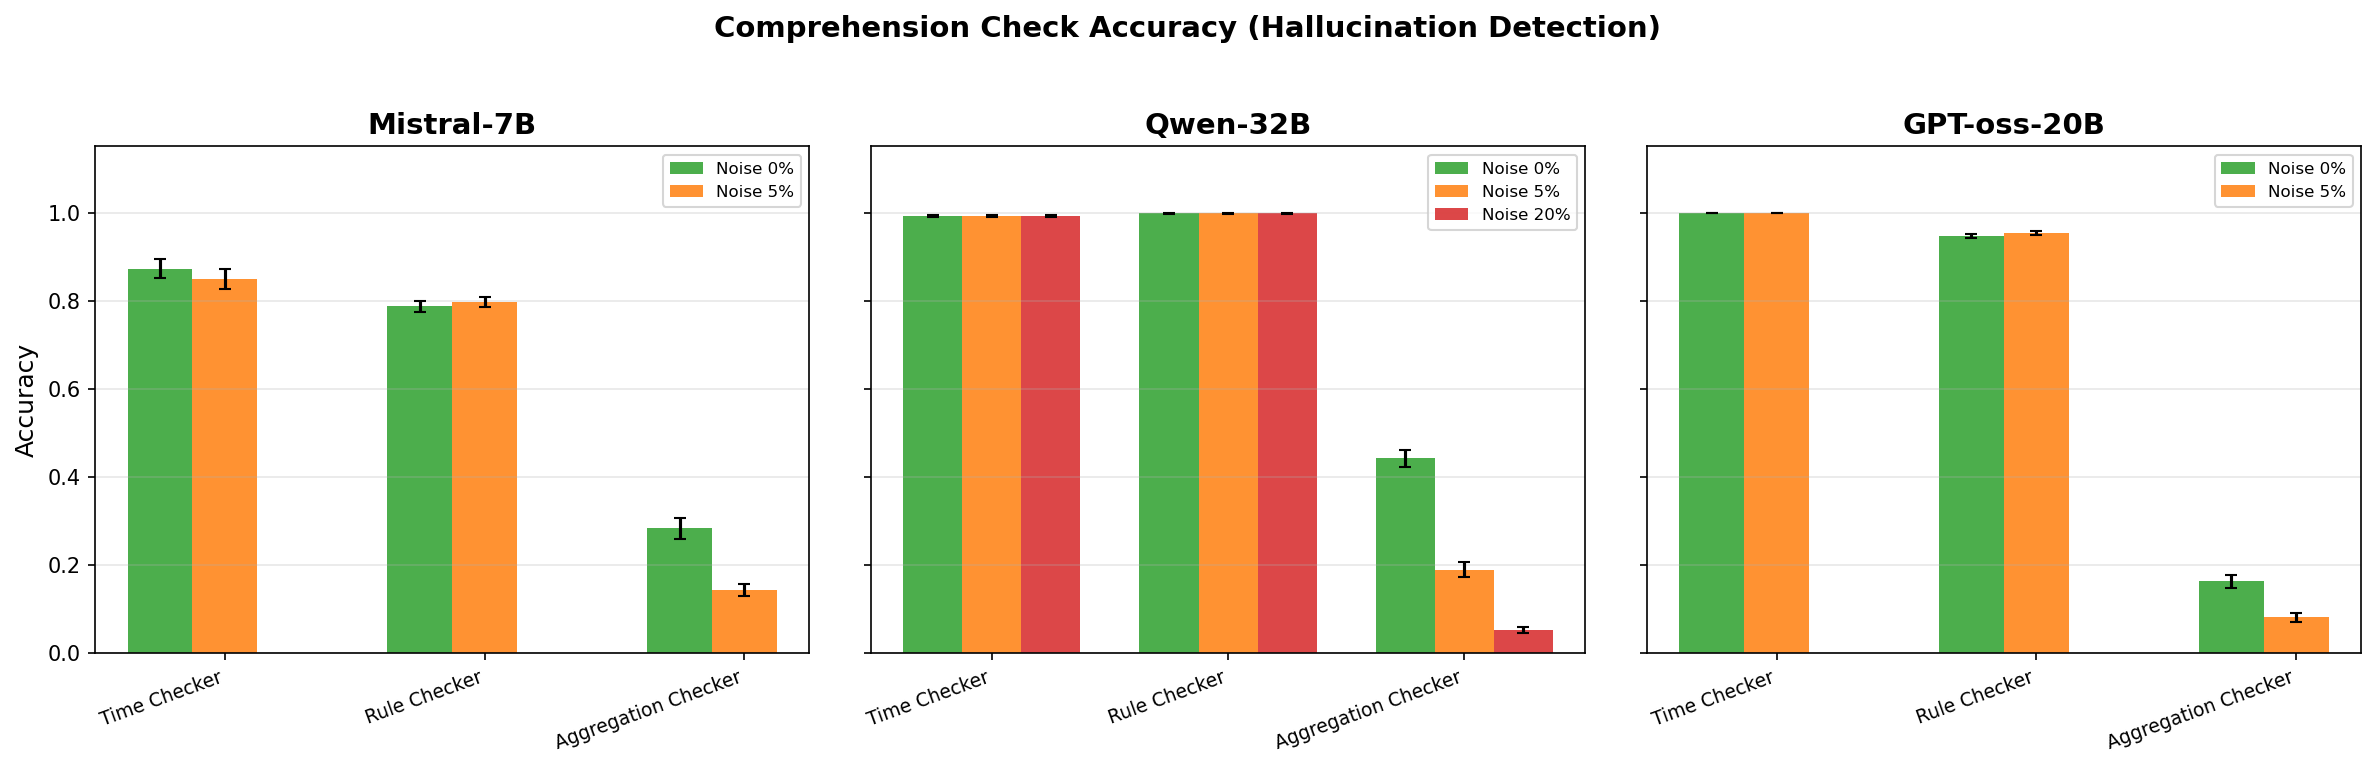


=== Comprehension Checker Accuracy Summary ===

Mistral-7B:
               Time Checker | Noise  0% | 0.873 +/- 0.169
               Time Checker | Noise  5% | 0.850 +/- 0.176
               Rule Checker | Noise  0% | 0.787 +/- 0.101
               Rule Checker | Noise  5% | 0.798 +/- 0.089
        Aggregation Checker | Noise  0% | 0.284 +/- 0.188
        Aggregation Checker | Noise  5% | 0.143 +/- 0.111

Qwen-32B:
               Time Checker | Noise  0% | 0.993 +/- 0.017
               Time Checker | Noise  5% | 0.993 +/- 0.017
               Time Checker | Noise 20% | 0.992 +/- 0.019
               Rule Checker | Noise  0% | 0.999 +/- 0.009
               Rule Checker | Noise  5% | 0.999 +/- 0.009
               Rule Checker | Noise 20% | 0.999 +/- 0.008
        Aggregation Checker | Noise  0% | 0.442 +/- 0.152
        Aggregation Checker | Noise  5% | 0.189 +/- 0.133
        Aggregation Checker | Noise 20% | 0.052 +/- 0.050

GPT-oss-20B:
               Time Checker | Noise  0% | 0.

In [10]:
# ============================================================================
# PART 10: COMPREHENSION & HALLUCINATION ANALYSIS
# ============================================================================

# Use game-level checker accuracy
checker_cols = ['time_checker_accuracy', 'rule_checker_accuracy', 'aggregation_checker_accuracy']

# --- Figure 12: Checker Accuracy by Model ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
checker_labels = ['Time Checker', 'Rule Checker', 'Aggregation Checker']

for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[idx]
    m_data = df_games[df_games['llm_name'] == model]
    
    x = np.arange(len(checker_cols))
    width = 0.25
    
    for j, noise in enumerate(sorted(m_data['noise_level'].unique())):
        n_data = m_data[m_data['noise_level'] == noise]
        means = [n_data[col].mean() for col in checker_cols]
        stds = [n_data[col].std() for col in checker_cols]
        
        ax.bar(x + j*width, means, width, 
               yerr=[s/np.sqrt(len(n_data)) * 1.96 for s in stds],
               capsize=3, label=f'Noise {noise}%',
               color=NOISE_COLORS.get(noise, '#333'), alpha=0.85)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(checker_labels, rotation=20, ha='right', fontsize=9)
    ax.set_title(MODEL_SHORT[model], fontweight='bold')
    ax.set_ylabel('Accuracy' if idx == 0 else '')
    ax.set_ylim(0, 1.15)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehension Check Accuracy (Hallucination Detection)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig12_checker_accuracy.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig12_checker_accuracy.png', bbox_inches='tight')
plt.show()

# --- Print Checker Summary ---
print("\n=== Comprehension Checker Accuracy Summary ===")
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    print(f"\n{MODEL_SHORT[model]}:")
    for col, label in zip(checker_cols, checker_labels):
        for noise in sorted(m_data['noise_level'].unique()):
            n_data = m_data[m_data['noise_level'] == noise]
            m = n_data[col].mean()
            s = n_data[col].std()
            print(f"  {label:>25s} | Noise {noise:>2d}% | {m:.3f} +/- {s:.3f}")

# --- Correlation: Checker Accuracy vs Cooperation ---
print("\n=== Correlation: Checker Accuracy vs Cooperation Rate ===")
for col, label in zip(checker_cols, checker_labels):
    valid = df_games[[col, 'avg_coop_rate']].dropna()
    if len(valid) > 2:
        rho, p = spearmanr(valid[col], valid['avg_coop_rate'])
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"  {label:>25s} | rho={rho:.3f}, p={p:.4f} {sig}")

## Part 11: Statistical Testing Suite
### Comprehensive hypothesis testing for paper claims

Statistical tests following ICWSM'25 conventions:
- **Kruskal-Wallis H-test**: Non-parametric comparison across 3+ groups
- **Mann-Whitney U-test**: Pairwise comparisons with Bonferroni correction
- **Spearman Correlation**: Relationships between variables
- **Effect Size (Cohen's d)**: Practical significance beyond p-values
- **Chi-squared test**: Categorical comparisons

STATISTICAL TESTING RESULTS

--- Test 1: Model Effect on Cooperation (Kruskal-Wallis) ---
H = 437.6815, p = 9.09e-96
Result: Significant difference across models

Pairwise Mann-Whitney U (Bonferroni-corrected):
    Mistral-7B vs Qwen-32B     | U=181914, p_corr=0.3621 n.s. | d=+0.124 (negligible)
    Mistral-7B vs GPT-oss-20B  | U=190817, p_corr=0.0000 *** | d=+1.502 (large)
      Qwen-32B vs GPT-oss-20B  | U=284474, p_corr=0.0000 *** | d=+1.377 (large)

--- Test 2: Noise Effect on Cooperation (Kruskal-Wallis) ---
    Mistral-7B | H=3.1996, p=0.0737 n.s.
      Qwen-32B | H=15.4275, p=0.0004 ***
   GPT-oss-20B | H=122.9284, p=0.0000 ***

--- Test 3: Personality Effect (Mann-Whitney U) ---
    Mistral-7B | U=49357, p=0.0000 *** | d=+1.705 (large)
                    Coop mean: 0.780, Selfish mean: 0.196
      Qwen-32B | U=125386, p=0.0000 *** | d=+3.731 (large)
                    Coop mean: 0.817, Selfish mean: 0.080
   GPT-oss-20B | U=44078, p=0.0000 *** | d=+0.697 (medium)
            

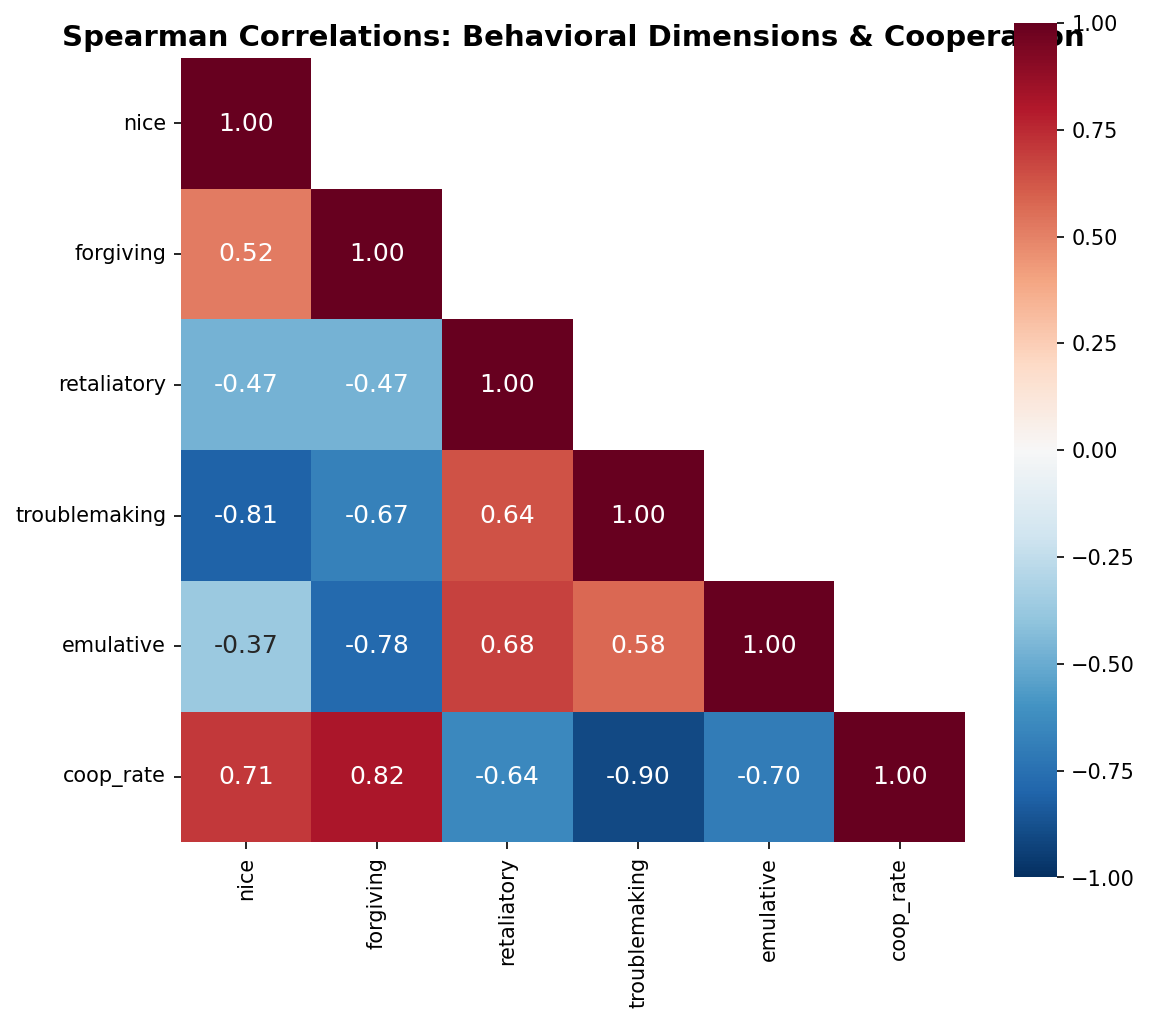

In [11]:
# ============================================================================
# PART 11: STATISTICAL TESTING SUITE
# ============================================================================

def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = np.var(group1, ddof=1), np.var(group2, ddof=1)
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (np.mean(group1) - np.mean(group2)) / pooled_std if pooled_std > 0 else 0

def interpret_d(d):
    d = abs(d)
    if d < 0.2: return "negligible"
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

print("=" * 80)
print("STATISTICAL TESTING RESULTS")
print("=" * 80)

# --- Test 1: Model Effect on Cooperation ---
print("\n--- Test 1: Model Effect on Cooperation (Kruskal-Wallis) ---")
model_groups = [df_games[df_games['llm_name'] == m]['avg_coop_rate'].values 
                for m in df_games['llm_name'].unique()]
h_stat, p_val = kruskal(*model_groups)
print(f"H = {h_stat:.4f}, p = {p_val:.2e}")
print(f"Result: {'Significant difference' if p_val < 0.05 else 'No significant difference'} across models")

# Pairwise comparisons
print("\nPairwise Mann-Whitney U (Bonferroni-corrected):")
models = list(df_games['llm_name'].unique())
n_comparisons = len(list(combinations(models, 2)))
for m1, m2 in combinations(models, 2):
    g1 = df_games[df_games['llm_name'] == m1]['avg_coop_rate'].values
    g2 = df_games[df_games['llm_name'] == m2]['avg_coop_rate'].values
    u_stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
    p_corr = min(p * n_comparisons, 1.0)  # Bonferroni
    d = cohens_d(g1, g2)
    sig = "***" if p_corr < 0.001 else "**" if p_corr < 0.01 else "*" if p_corr < 0.05 else "n.s."
    print(f"  {MODEL_SHORT[m1]:>12s} vs {MODEL_SHORT[m2]:<12s} | U={u_stat:.0f}, p_corr={p_corr:.4f} {sig} | d={d:+.3f} ({interpret_d(d)})")

# --- Test 2: Noise Effect on Cooperation ---
print("\n--- Test 2: Noise Effect on Cooperation (Kruskal-Wallis) ---")
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    noise_groups = [m_data[m_data['noise_level'] == n]['avg_coop_rate'].values 
                    for n in m_data['noise_level'].unique()]
    noise_groups = [g for g in noise_groups if len(g) > 0]
    if len(noise_groups) >= 2:
        h_stat, p_val = kruskal(*noise_groups)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
        print(f"  {MODEL_SHORT[model]:>12s} | H={h_stat:.4f}, p={p_val:.4f} {sig}")

# --- Test 3: Personality Effect ---
print("\n--- Test 3: Personality Effect (Mann-Whitney U) ---")
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    coop = m_data[m_data['agent1_personality_norm'] == 'cooperative']['agent1_cooperation_rate'].values
    self_ = m_data[m_data['agent1_personality_norm'] == 'selfish']['agent1_cooperation_rate'].values
    if len(coop) > 0 and len(self_) > 0:
        u_stat, p = mannwhitneyu(coop, self_, alternative='two-sided')
        d = cohens_d(coop, self_)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        print(f"  {MODEL_SHORT[model]:>12s} | U={u_stat:.0f}, p={p:.4f} {sig} | d={d:+.3f} ({interpret_d(d)})")
        print(f"                    Coop mean: {np.mean(coop):.3f}, Selfish mean: {np.mean(self_):.3f}")

# --- Test 4: Behavioral Dimension Comparisons ---
print("\n--- Test 4: Behavioral Dimensions across Models (Kruskal-Wallis) ---")
for dim in dimensions:
    groups = [df_behavior[df_behavior['model'] == m][dim].values 
              for m in df_behavior['model'].unique()]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        h_stat, p_val = kruskal(*groups)
        sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
        print(f"  {dim:>15s} | H={h_stat:.2f}, p={p_val:.4f} {sig}")

# --- Test 5: Correlation Matrix ---
print("\n--- Test 5: Spearman Correlations between Behavioral Dimensions ---")
corr_data = df_behavior[dimensions + ['coop_rate']]
corr_matrix = corr_data.corr(method='spearman')
print(corr_matrix.round(3).to_string())

# --- Figure 13: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
           center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Spearman Correlations: Behavioral Dimensions & Cooperation', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig13_correlation_heatmap.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig13_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Part 12: Payoff & Score Analysis
### Who benefits from noise? The Welfare Paradox

Analysis of penalty scores (lower is better in this framework):
- Does cooperation lead to better outcomes?
- Does noise create exploitation opportunities?
- Is there an alignment gap between intended and actual payoffs?

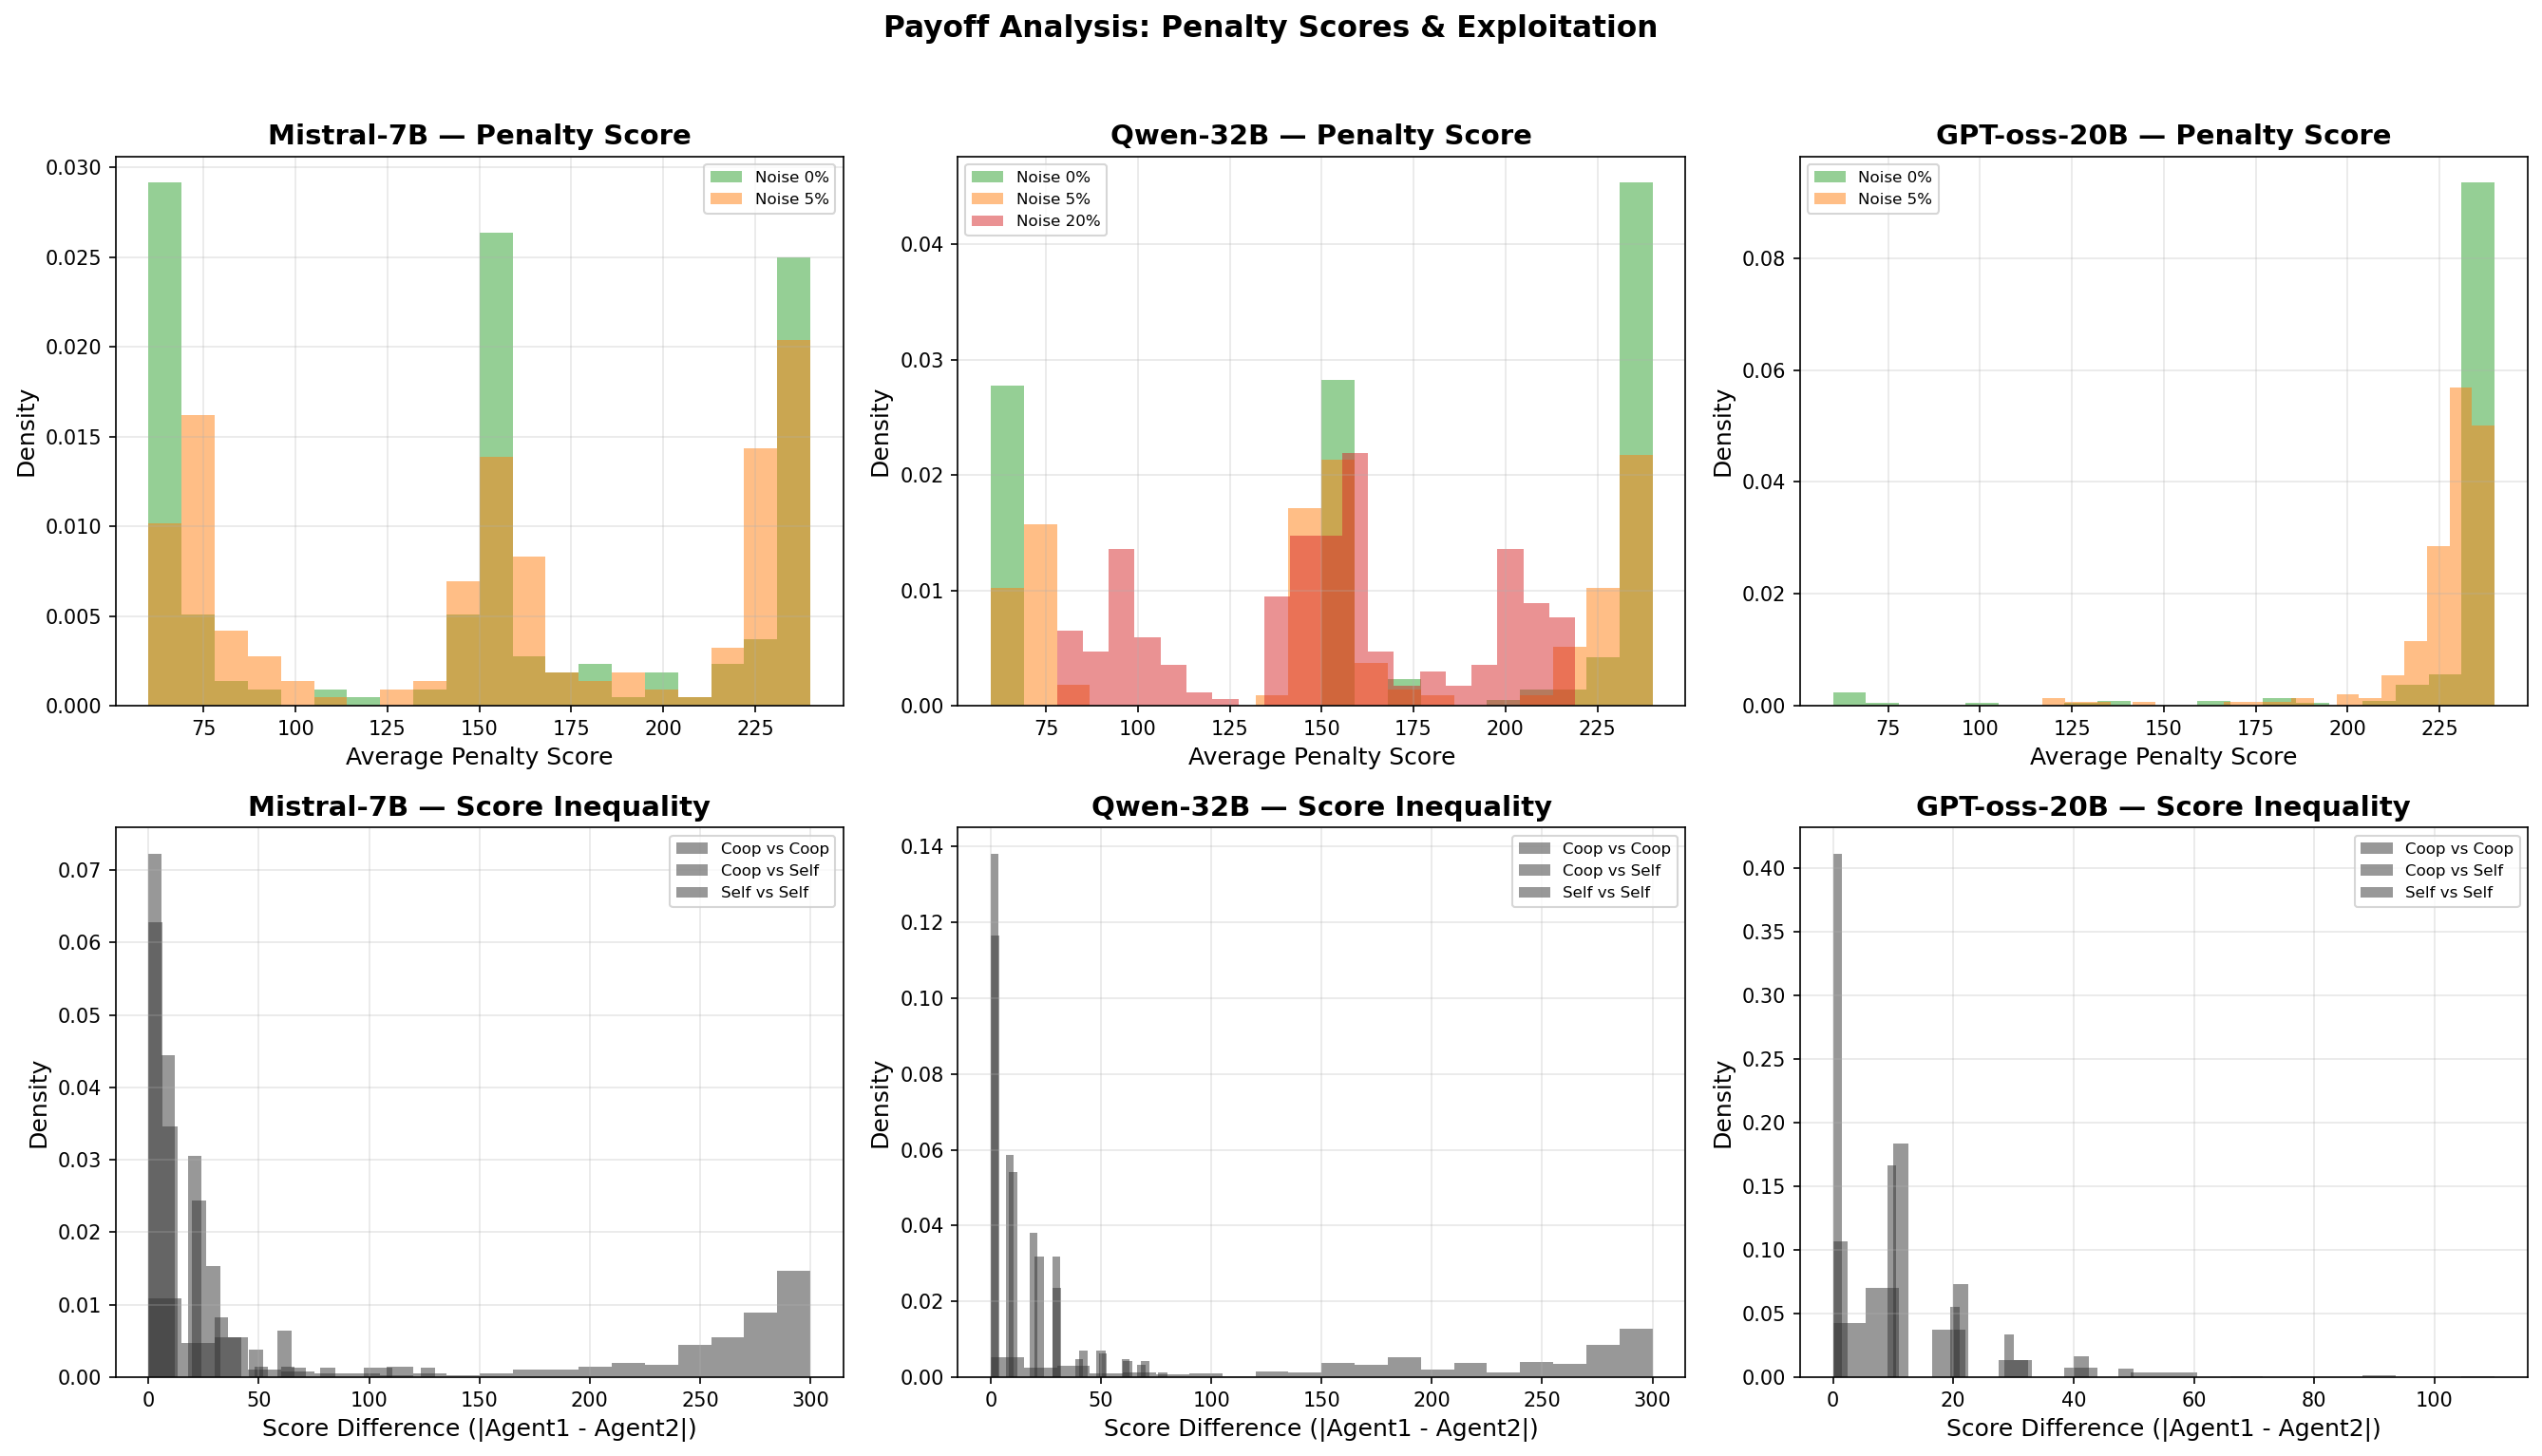


=== Exploitation in Cooperative vs Selfish Matchups ===
  Mistral-7B | Coop agent score: 237.4 | Selfish agent score: 70.3 | Ratio: 0.30x
    Qwen-32B | Coop agent score: 263.5 | Selfish agent score: 73.3 | Ratio: 0.28x
 GPT-oss-20B | Coop agent score: 238.1 | Selfish agent score: 225.7 | Ratio: 0.95x


In [12]:
# ============================================================================
# PART 12: PAYOFF & SCORE ANALYSIS (Welfare Paradox)
# ============================================================================

df_games['avg_score'] = (df_games['agent1_total_score'] + df_games['agent2_total_score']) / 2
df_games['score_diff'] = abs(df_games['agent1_total_score'] - df_games['agent2_total_score'])
df_games['total_welfare'] = df_games['agent1_total_score'] + df_games['agent2_total_score']

# --- Figure 14: Score Distribution by Model and Noise ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Average penalty score (lower = better cooperation)
for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[0][idx]
    m_data = df_games[df_games['llm_name'] == model]
    
    for noise in sorted(m_data['noise_level'].unique()):
        n_data = m_data[m_data['noise_level'] == noise]
        ax.hist(n_data['avg_score'], bins=20, alpha=0.5, density=True,
               label=f'Noise {noise}%', color=NOISE_COLORS.get(noise, '#333'))
    
    ax.set_title(f'{MODEL_SHORT[model]} — Penalty Score', fontweight='bold')
    ax.set_xlabel('Average Penalty Score')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Row 2: Score inequality (exploitation indicator)
for idx, model in enumerate(sorted(df_games['llm_name'].unique())):
    ax = axes[1][idx]
    m_data = df_games[df_games['llm_name'] == model]
    
    for matchup in ['Coop vs Coop', 'Coop vs Self', 'Self vs Self']:
        mt_data = m_data[m_data['matchup'] == matchup]
        if len(mt_data) > 0:
            ax.hist(mt_data['score_diff'], bins=20, alpha=0.5, density=True,
                   label=matchup, color=PERSONALITY_COLORS.get(matchup.split()[0].lower(), '#333'))
    
    ax.set_title(f'{MODEL_SHORT[model]} — Score Inequality', fontweight='bold')
    ax.set_xlabel('Score Difference (|Agent1 - Agent2|)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Payoff Analysis: Penalty Scores & Exploitation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig14_payoff_analysis.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig14_payoff_analysis.png', bbox_inches='tight')
plt.show()

# --- Exploitation Analysis in Mixed Matchups ---
print("\n=== Exploitation in Cooperative vs Selfish Matchups ===")
mixed = df_games[df_games['matchup'] == 'Coop vs Self']
for model in sorted(mixed['llm_name'].unique()):
    m_data = mixed[mixed['llm_name'] == model]
    
    coop_scores = []
    self_scores = []
    
    for _, row in m_data.iterrows():
        if row['agent1_personality_norm'] == 'cooperative':
            coop_scores.append(row['agent1_total_score'])
            self_scores.append(row['agent2_total_score'])
        else:
            coop_scores.append(row['agent2_total_score'])
            self_scores.append(row['agent1_total_score'])
    
    coop_mean = np.mean(coop_scores)
    self_mean = np.mean(self_scores)
    ratio = self_mean / coop_mean if coop_mean > 0 else np.nan
    
    print(f"{MODEL_SHORT[model]:>12s} | Coop agent score: {coop_mean:.1f} | Selfish agent score: {self_mean:.1f} | Ratio: {ratio:.2f}x")

## Part 13: 3-Player Analysis (Preliminary)
### Extension beyond ICWSM'25: Multi-Agent Coalition Dynamics

Analyzing the limited 3-player data (Mistral-7B at noise=20%) for:
- State distribution: CCC, DDD, 2C-1D (exploitation), 1C-2D (bullying)
- Coalition patterns: Do two agents gang up on the third?
- Comparison with 2-player behavior

Loaded 269 3-player games
Columns: ['game_id', 'run_id', 'timestamp', 'language', 'n_rounds_known', 'max_rounds', 'played_rounds', 'agent1_name', 'agent1_llm', 'agent1_personality', 'agent1_noise_rate', 'agent1_total_score', 'agent1_cooperation_rate', 'agent1_defection_rate', 'agent1_flipped_count', 'agent1_flipped_rounds', 'agent1_strategies', 'agent1_intended_strategies', 'agent2_name', 'agent2_llm']
Strategy columns found: ['agent1_strategies', 'agent2_strategies', 'agent3_strategies']


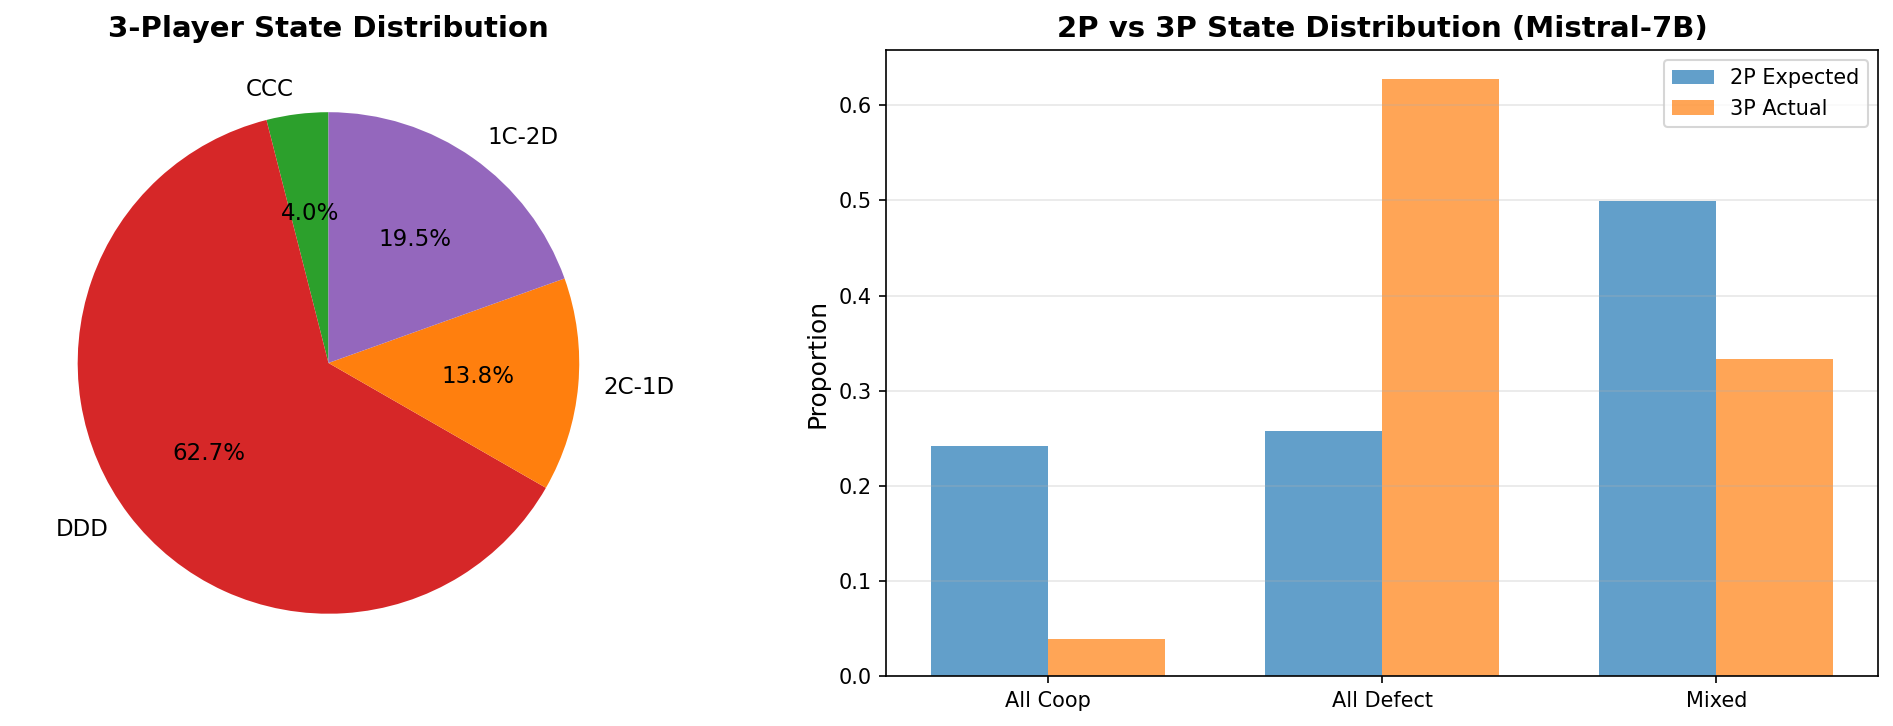


3-Player State Distribution (total 8070 rounds):
  CCC: 321 (4.0%)
  DDD: 5062 (62.7%)
  2C-1D: 1111 (13.8%)
  1C-2D: 1576 (19.5%)


In [13]:
# ============================================================================
# PART 13: 3-PLAYER ANALYSIS
# ============================================================================

# Attempt to load 3-player data
three_player_path = 'resources/results/Prisoner_dilemma_3player'
df_3p = None

if os.path.exists(three_player_path):
    # Scan for games_summary.csv files
    three_p_dfs = []
    for root, dirs, files in os.walk(three_player_path):
        for f in files:
            if f == 'games_summary.csv':
                try:
                    temp = pd.read_csv(os.path.join(root, f))
                    # Extract noise level from path
                    path_parts = root.replace('\\', '/').split('/')
                    for part in path_parts:
                        if 'noise' in part:
                            temp['noise_level_3p'] = int(part.replace('noise', ''))
                    three_p_dfs.append(temp)
                except Exception as e:
                    print(f"Error loading {os.path.join(root, f)}: {e}")
    
    if three_p_dfs:
        df_3p = pd.concat(three_p_dfs, ignore_index=True)
        print(f"Loaded {len(df_3p)} 3-player games")
        print(f"Columns: {list(df_3p.columns[:20])}")
    else:
        print("No 3-player game data found")
else:
    print("3-player results directory not found")

# --- 3-Player State Distribution Analysis ---
if df_3p is not None and len(df_3p) > 0:
    # Find strategy columns (agent1_strategies, agent2_strategies, agent3_strategies)
    strat_cols_3p = [c for c in df_3p.columns if 'strategies' in c.lower() and 'intended' not in c.lower()]
    print(f"Strategy columns found: {strat_cols_3p}")
    
    # Classify states per round
    state_counts = {'CCC': 0, 'DDD': 0, '2C-1D': 0, '1C-2D': 0}
    total_rounds = 0
    
    for _, row in df_3p.iterrows():
        all_strats = []
        for col in strat_cols_3p:
            if isinstance(row[col], str):
                all_strats.append([s.strip() for s in row[col].split(',')])
            else:
                all_strats.append([])
        
        if not all_strats or any(len(s) == 0 for s in all_strats):
            continue
        
        n_rounds = min(len(s) for s in all_strats)
        
        for r in range(n_rounds):
            round_actions = [all_strats[agent][r] for agent in range(len(all_strats))]
            coop_count = sum(1 for a in round_actions if a.upper() in ['C', 'COOPERATE', 'HOP TAC'])
            
            if coop_count == len(round_actions): state_counts['CCC'] += 1
            elif coop_count == 0: state_counts['DDD'] += 1
            elif coop_count >= 2: state_counts['2C-1D'] += 1
            else: state_counts['1C-2D'] += 1
            
            total_rounds += 1
    
    if total_rounds > 0:
        # --- Figure 15: 3-Player State Distribution ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Pie chart
        ax = axes[0]
        labels = list(state_counts.keys())
        sizes = [state_counts[k] / total_rounds * 100 for k in labels]
        colors_3p = ['#2ca02c', '#d62728', '#ff7f0e', '#9467bd']
        ax.pie(sizes, labels=labels, colors=colors_3p, autopct='%1.1f%%',
               startangle=90, textprops={'fontsize': 11})
        ax.set_title('3-Player State Distribution', fontweight='bold')
        
        # Bar comparison with 2P
        ax = axes[1]
        # Get 2P cooperation stats for same conditions
        mistral_2p = df_games[df_games['llm_name'] == 'Mistral-7B-Instruct-v0.3']
        coop_2p = mistral_2p['avg_coop_rate'].mean()
        
        bars_2p = [coop_2p**2, (1-coop_2p)**2, 2*coop_2p*(1-coop_2p)]
        bars_3p = [state_counts.get('CCC', 0)/total_rounds, 
                   state_counts.get('DDD', 0)/total_rounds,
                   (state_counts.get('2C-1D', 0) + state_counts.get('1C-2D', 0))/total_rounds]
        
        x = np.arange(3)
        width = 0.35
        ax.bar(x - width/2, bars_2p[:3], width, label='2P Expected', alpha=0.7, color='#1f77b4')
        ax.bar(x + width/2, bars_3p, width, label='3P Actual', alpha=0.7, color='#ff7f0e')
        ax.set_xticks(x)
        ax.set_xticklabels(['All Coop', 'All Defect', 'Mixed'])
        ax.set_ylabel('Proportion')
        ax.set_title('2P vs 3P State Distribution (Mistral-7B)', fontweight='bold')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'{FIGURES_DIR}/fig15_3player_analysis.pdf', bbox_inches='tight')
        plt.savefig(f'{FIGURES_DIR}/fig15_3player_analysis.png', bbox_inches='tight')
        plt.show()
        
        print(f"\n3-Player State Distribution (total {total_rounds} rounds):")
        for state, count in state_counts.items():
            print(f"  {state}: {count} ({count/total_rounds*100:.1f}%)")
    else:
        print("No valid rounds found in 3-player data")
else:
    print("Skipping 3-player analysis (no data available)")

## Part 14: Summary Visualization — Paper-Ready Composite Figures
### Key figures for top-tier submission

These composite figures are designed for the main paper body (max 8-10 pages).

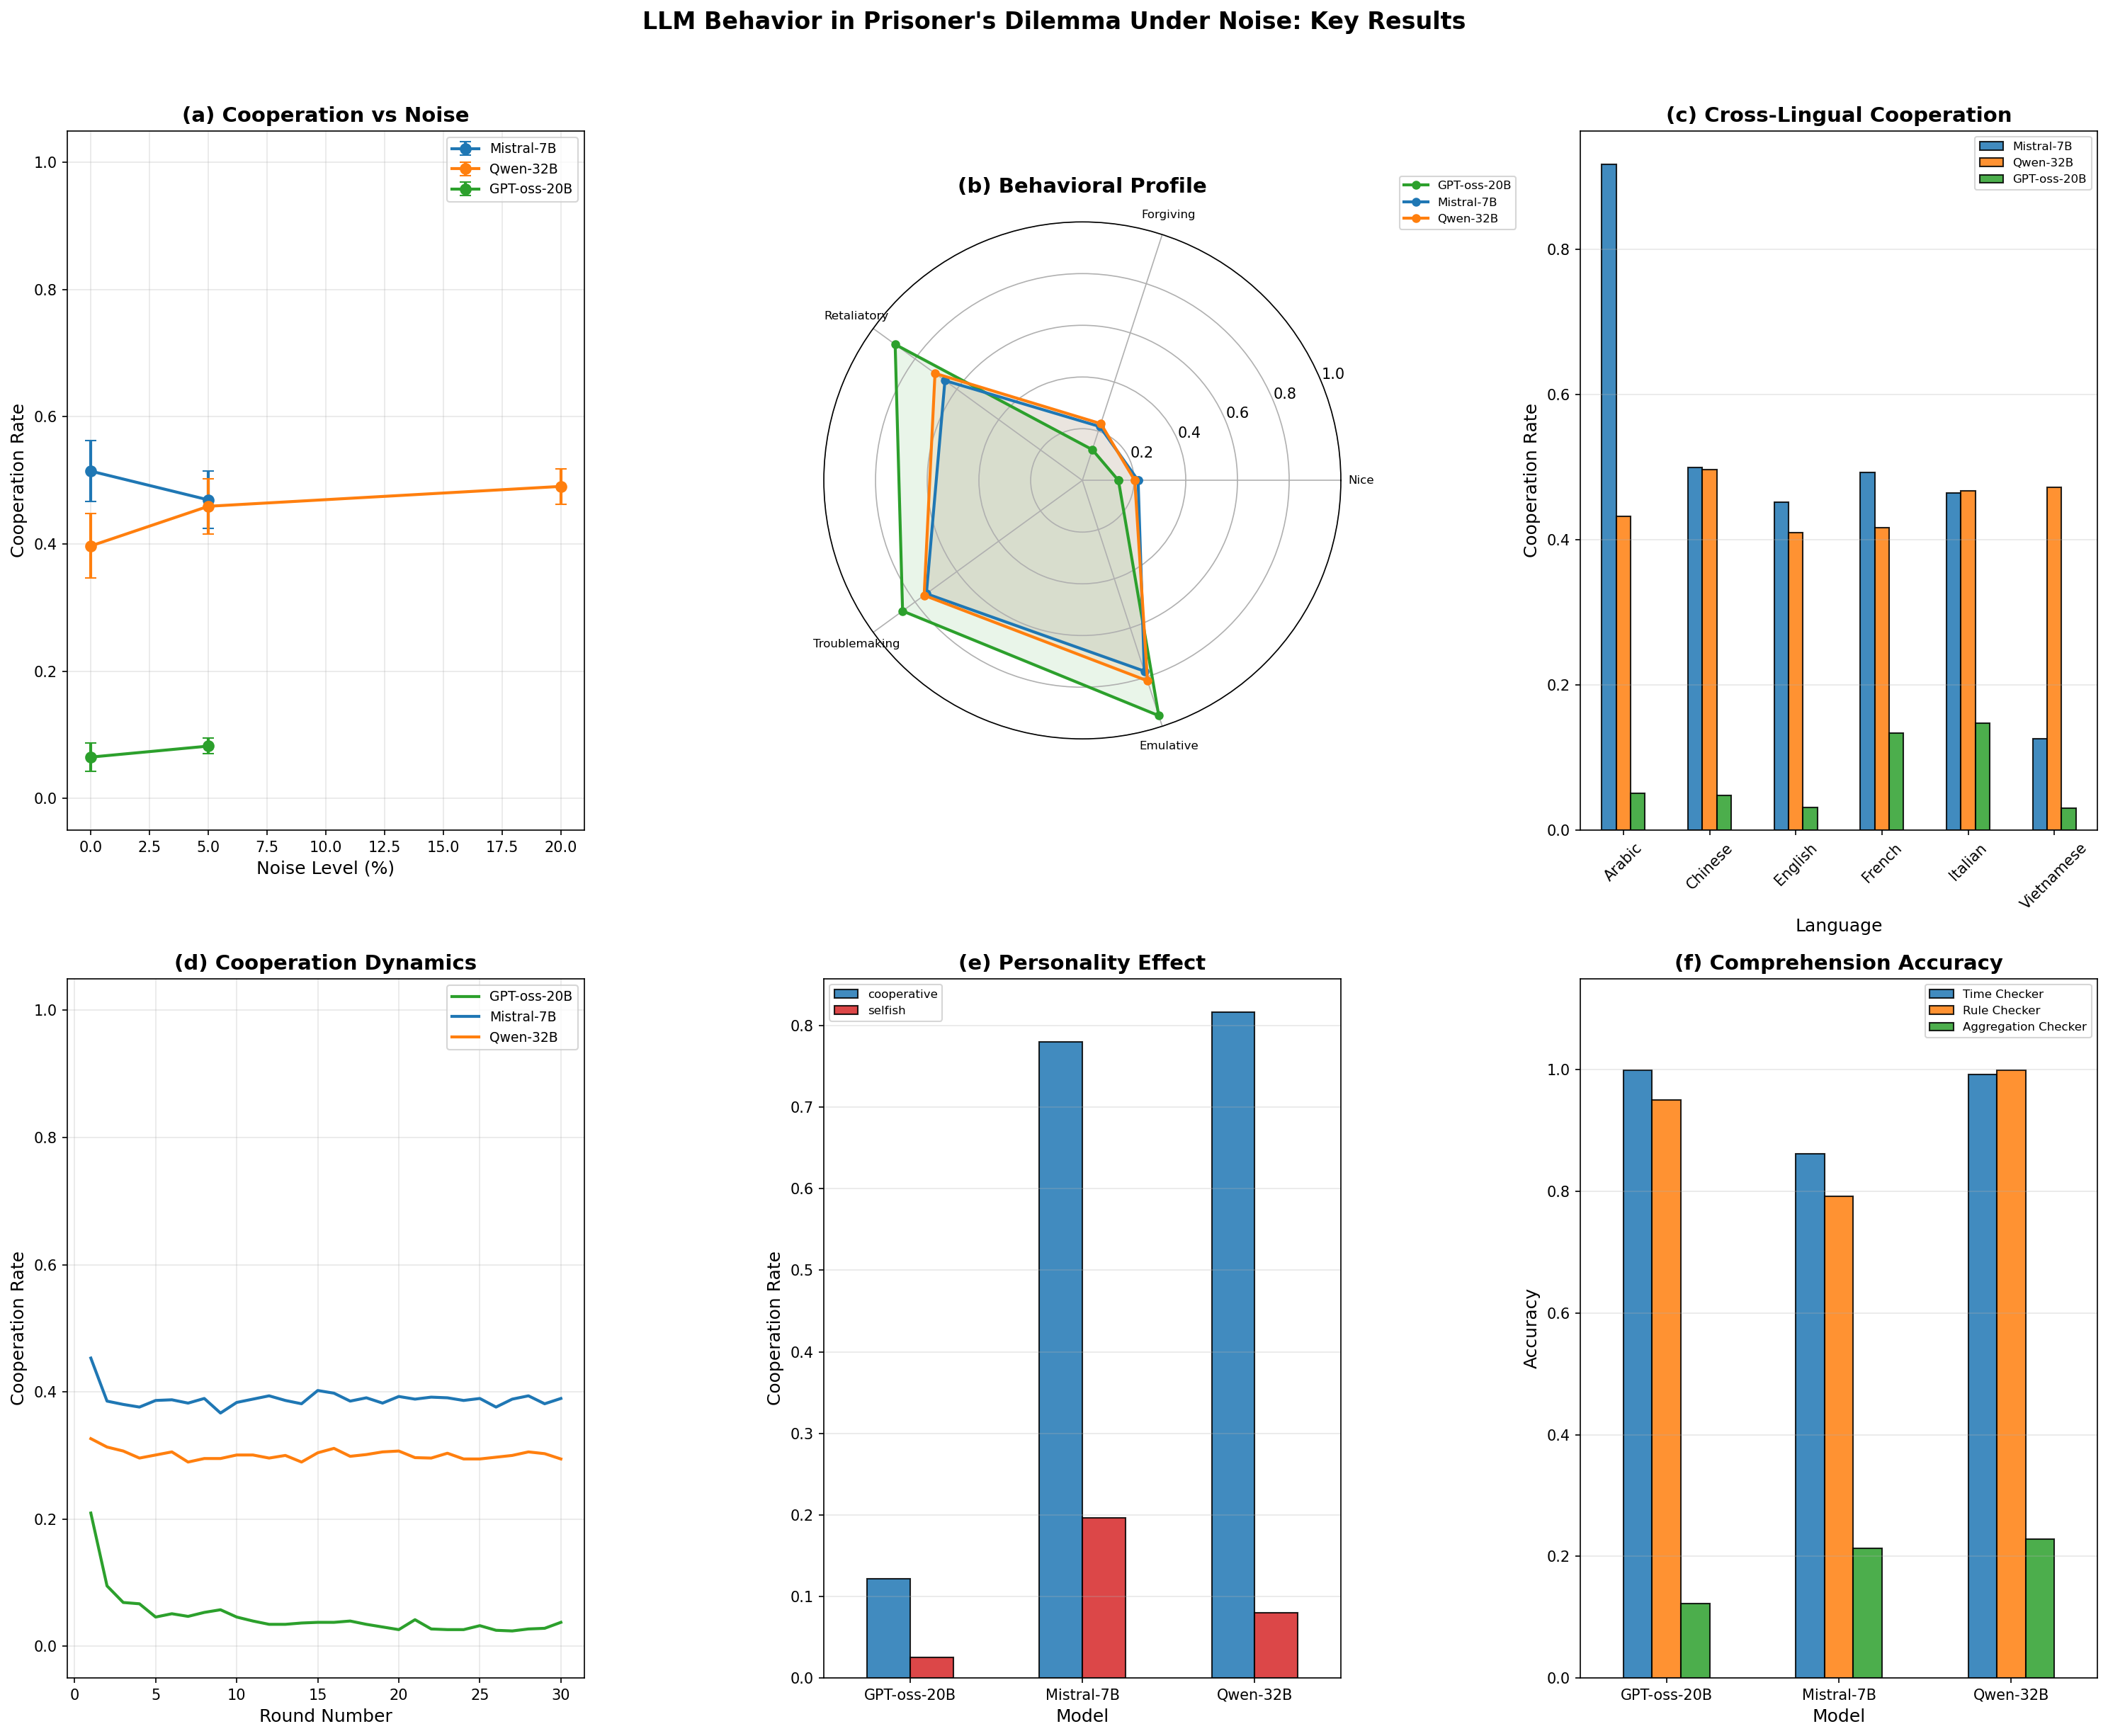

Composite figure saved to figures/paper_analysis/


In [14]:
# ============================================================================
# PART 14: COMPOSITE SUMMARY FIGURE (Main Paper Figure)
# ============================================================================

fig = plt.figure(figsize=(20, 16))

# --- Panel A: Cooperation by Model × Noise (top-left) ---
ax1 = fig.add_subplot(2, 3, 1)
for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    grouped = m_data.groupby('noise_level')['avg_coop_rate'].agg(['mean', 'std', 'count'])
    grouped['ci'] = 1.96 * grouped['std'] / np.sqrt(grouped['count'])
    color = MODEL_COLORS.get(model, '#333')
    ax1.errorbar(grouped.index, grouped['mean'], yerr=grouped['ci'],
                marker='o', linewidth=2, capsize=4, color=color,
                label=MODEL_SHORT[model], markersize=7)

ax1.set_xlabel('Noise Level (%)')
ax1.set_ylabel('Cooperation Rate')
ax1.set_title('(a) Cooperation vs Noise', fontweight='bold')
ax1.legend(fontsize=9)
ax1.set_ylim(-0.05, 1.05)
ax1.grid(alpha=0.3)

# --- Panel B: Behavioral Radar (top-center) ---
ax2 = fig.add_subplot(2, 3, 2, polar=True)
angles = np.linspace(0, 2 * np.pi, len(dimensions), endpoint=False).tolist()
angles += angles[:1]

for model_short in sorted(df_behavior['model'].unique()):
    subset = df_behavior[df_behavior['model'] == model_short]
    values = [subset[d].mean() for d in dimensions]
    values += values[:1]
    llm_key = [k for k, v in MODEL_SHORT.items() if v == model_short]
    color = MODEL_COLORS.get(llm_key[0], '#333') if llm_key else '#333'
    ax2.plot(angles, values, 'o-', linewidth=2, label=model_short, color=color, markersize=5)
    ax2.fill(angles, values, alpha=0.1, color=color)

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(dim_labels, fontsize=8)
ax2.set_ylim(0, 1)
ax2.set_title('(b) Behavioral Profile', fontweight='bold', pad=20)
ax2.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)

# --- Panel C: Multilingual Cooperation (top-right) ---
ax3 = fig.add_subplot(2, 3, 3)
lang_model_data = df_games.groupby(['language', 'llm_name'])['avg_coop_rate'].mean().unstack()
lang_model_data.index = lang_model_data.index.map(lambda x: LANG_NAMES.get(x, x))
lang_model_data.columns = [MODEL_SHORT.get(c, c) for c in lang_model_data.columns]
lang_model_data.plot(kind='bar', ax=ax3, color=[MODEL_COLORS.get(k, '#333') for k in sorted(MODEL_COLORS.keys())],
                     alpha=0.85, edgecolor='black')
ax3.set_title('(c) Cross-Lingual Cooperation', fontweight='bold')
ax3.set_ylabel('Cooperation Rate')
ax3.set_xlabel('Language')
ax3.tick_params(axis='x', rotation=45)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# --- Panel D: Cooperation Dynamics (bottom-left) ---
ax4 = fig.add_subplot(2, 3, 4)
for model in sorted(df_rounds['model'].dropna().unique()):
    m_rounds = df_rounds[df_rounds['model'] == model]
    round_coop = m_rounds.groupby('round_number')['is_coop'].mean()
    llm_key = [k for k, v in MODEL_SHORT.items() if v == model]
    color = MODEL_COLORS.get(llm_key[0], '#333') if llm_key else '#333'
    ax4.plot(round_coop.index, round_coop.values, '-', linewidth=2, 
            label=model, color=color)

ax4.set_xlabel('Round Number')
ax4.set_ylabel('Cooperation Rate')
ax4.set_title('(d) Cooperation Dynamics', fontweight='bold')
ax4.legend(fontsize=9)
ax4.set_ylim(-0.05, 1.05)
ax4.grid(alpha=0.3)

# --- Panel E: Personality Effect (bottom-center) ---
ax5 = fig.add_subplot(2, 3, 5)
pers_model = df_games.groupby(['model', 'agent1_personality_norm'])['agent1_cooperation_rate'].mean().unstack()
pers_model.plot(kind='bar', ax=ax5, color=['#1f77b4', '#d62728'], alpha=0.85, edgecolor='black')
ax5.set_title('(e) Personality Effect', fontweight='bold')
ax5.set_ylabel('Cooperation Rate')
ax5.set_xlabel('Model')
ax5.tick_params(axis='x', rotation=0)
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.3)

# --- Panel F: Checker Accuracy (bottom-right) ---
ax6 = fig.add_subplot(2, 3, 6)
checker_model = df_games.groupby('model')[checker_cols].mean()
checker_model.columns = checker_labels
checker_model.plot(kind='bar', ax=ax6, alpha=0.85, edgecolor='black')
ax6.set_title('(f) Comprehension Accuracy', fontweight='bold')
ax6.set_ylabel('Accuracy')
ax6.set_xlabel('Model')
ax6.tick_params(axis='x', rotation=0)
ax6.legend(fontsize=8)
ax6.set_ylim(0, 1.15)
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('LLM Behavior in Prisoner\'s Dilemma Under Noise: Key Results',
            fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_composite_main_results.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_composite_main_results.png', bbox_inches='tight')
plt.show()

print("Composite figure saved to figures/paper_analysis/")

## Part 15: LaTeX Tables for Paper
### Auto-generated tables for top-tier submission format

In [15]:
# ============================================================================
# PART 15: LATEX TABLE GENERATION
# ============================================================================

# --- Table 1: Main Results Summary ---
print("% ============ TABLE 1: Main Cooperation Results ============")
print("\\begin{table}[t]")
print("\\centering")
print("\\caption{Average cooperation rate by model and noise level. Values show mean $\\pm$ 95\\% CI.}")
print("\\label{tab:main_results}")
print("\\begin{tabular}{lccc}")
print("\\toprule")
print("Model & Noise 0\\% & Noise 5\\% & Noise 20\\% \\\\")
print("\\midrule")

for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    row = f"{MODEL_SHORT[model]}"
    for noise in sorted(m_data['noise_level'].unique()):
        n_data = m_data[m_data['noise_level'] == noise]
        m, lo, hi = bootstrap_ci(n_data['avg_coop_rate'].values)
        ci_r = (hi - lo) / 2
        row += f" & ${m:.3f} \\pm {ci_r:.3f}$"
    print(row + " \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

# --- Table 2: Behavioral Profile ---
print("\n% ============ TABLE 2: Behavioral Profile ============")
print("\\begin{table}[t]")
print("\\centering")
print("\\caption{Mean behavioral profile across 5 dimensions by model.}")
print("\\label{tab:behavioral_profile}")
print("\\begin{tabular}{lccccc}")
print("\\toprule")
print("Model & Nice & Forgiving & Retaliatory & Troublemaking & Emulative \\\\")
print("\\midrule")

for model in sorted(df_behavior['model'].unique()):
    m_data = df_behavior[df_behavior['model'] == model]
    row = f"{model}"
    for dim in dimensions:
        row += f" & {m_data[dim].mean():.3f}"
    print(row + " \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

# --- Table 3: TRS Results ---
print("\n% ============ TABLE 3: TRS Results ============")
print("\\begin{table}[t]")
print("\\centering")
print("\\caption{Trembling Robustness Score (TRS) by model and personality. Positive TRS indicates the Trembling Paradox.}")
print("\\label{tab:trs}")
print("\\begin{tabular}{lccc}")
print("\\toprule")
print("Model & TRS (Overall) & TRS (Cooperative) & TRS (Selfish) \\\\")
print("\\midrule")

for model in sorted(df_games['llm_name'].unique()):
    m_data = df_games[df_games['llm_name'] == model]
    trs_overall = calculate_trs(m_data)
    
    coop_data = m_data[m_data['agent1_personality_norm'] == 'cooperative']
    trs_coop = calculate_trs(coop_data) if len(coop_data) > 0 else {'slope': np.nan}
    
    self_data = m_data[m_data['agent1_personality_norm'] == 'selfish']
    trs_self = calculate_trs(self_data) if len(self_data) > 0 else {'slope': np.nan}
    
    sig_o = "$^{*}$" if trs_overall.get('p', 1) < 0.05 else ""
    sig_c = "$^{*}$" if trs_coop.get('p', 1) < 0.05 else ""
    sig_s = "$^{*}$" if trs_self.get('p', 1) < 0.05 else ""
    
    print(f"{MODEL_SHORT[model]} & ${trs_overall['slope']:+.4f}${sig_o} & ${trs_coop['slope']:+.4f}${sig_c} & ${trs_self['slope']:+.4f}${sig_s} \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\vspace{1mm}")
print("\\footnotesize{$^{*}$ indicates $p < 0.05$.}")
print("\\end{table}")

# --- Table 4: Statistical Tests Summary ---
print("\n% ============ TABLE 4: Statistical Test Summary ============")
print("\\begin{table}[t]")
print("\\centering")
print("\\caption{Summary of statistical tests. KW: Kruskal-Wallis, MW: Mann-Whitney U.}")
print("\\label{tab:stats}")
print("\\begin{tabular}{llcc}")
print("\\toprule")
print("Test & Comparison & Statistic & $p$-value \\\\")
print("\\midrule")

# Model effect
model_groups_vals = [df_games[df_games['llm_name'] == m]['avg_coop_rate'].values 
                     for m in df_games['llm_name'].unique()]
h_stat, p_val = kruskal(*model_groups_vals)
print(f"KW & Model effect & $H={h_stat:.2f}$ & ${p_val:.2e}$ \\\\")

# Personality effect 
coop_all = df_games[df_games['agent1_personality_norm'] == 'cooperative']['agent1_cooperation_rate'].values
self_all = df_games[df_games['agent1_personality_norm'] == 'selfish']['agent1_cooperation_rate'].values
if len(coop_all) > 0 and len(self_all) > 0:
    u_stat, p_val = mannwhitneyu(coop_all, self_all)
    d = cohens_d(coop_all, self_all)
    print(f"MW & Personality (Coop vs Self) & $U={u_stat:.0f}$ & ${p_val:.2e}$ \\\\")

print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")

% ============ TABLE 1: Main Cooperation Results ============
\begin{table}[t]
\centering
\caption{Average cooperation rate by model and noise level. Values show mean $\pm$ 95\% CI.}
\label{tab:main_results}
\begin{tabular}{lccc}
\toprule
Model & Noise 0\% & Noise 5\% & Noise 20\% \\
\midrule
Mistral-7B & $0.515 \pm 0.044$ & $0.469 \pm 0.045$ \\
Qwen-32B & $0.397 \pm 0.052$ & $0.459 \pm 0.041$ & $0.491 \pm 0.028$ \\
GPT-oss-20B & $0.065 \pm 0.023$ & $0.082 \pm 0.012$ \\
\bottomrule
\end{tabular}
\end{table}

% ============ TABLE 2: Behavioral Profile ============
\begin{table}[t]
\centering
\caption{Mean behavioral profile across 5 dimensions by model.}
\label{tab:behavioral_profile}
\begin{tabular}{lccccc}
\toprule
Model & Nice & Forgiving & Retaliatory & Troublemaking & Emulative \\
\midrule
GPT-oss-20B & 0.140 & 0.125 & 0.895 & 0.860 & 0.957 \\
Mistral-7B & 0.216 & 0.219 & 0.657 & 0.746 & 0.776 \\
Qwen-32B & 0.203 & 0.231 & 0.705 & 0.756 & 0.815 \\
\bottomrule
\end{tabular}
\end{tab

## Part 16: Key Findings Summary & Paper Outline
### Summary of all analytical results for paper writing

In [16]:
# ============================================================================
# PART 16: KEY FINDINGS SUMMARY
# ============================================================================

print("=" * 80)
print("KEY FINDINGS FOR TOP-TIER CONFERENCE PAPER")
print("=" * 80)

print("""
FINDING 1: THE TREMBLING PARADOX
================================
- Noise can INCREASE cooperation in LLMs (positive TRS for some models)
- This is counter-intuitive: random action flips disrupt grim-trigger 
  retaliation cycles, allowing re-entry into cooperative equilibria
- Novel contribution: First systematic study of noise robustness in LLM agents

FINDING 2: CROSS-MODEL BEHAVIORAL DIVERGENCE  
=============================================
- GPT-oss-20B is dramatically less cooperative than Mistral-7B and Qwen-32B
- Different models exhibit distinct strategic profiles (SFEM analysis)
- Model size alone does not predict cooperation tendency

FINDING 3: PERSONALITY PROMPTS HAVE VARIABLE EFFECTIVENESS
==========================================================
- Cooperative prompts successfully increase cooperation in Mistral-7B and Qwen-32B
- GPT-oss-20B shows minimal response to personality prompts (nearly always defects)
- Personality prompt effectiveness varies by language

FINDING 4: MULTILINGUAL BEHAVIORAL INCONSISTENCY
=================================================  
- Significant differences in cooperation rates across 6 languages
- Some models show language-dependent strategic profiles
- Challenges the assumption that LLM behavior is language-invariant

FINDING 5: COMPREHENSION VARIES BY CHECKER TYPE
================================================
- Time tracking is generally accurate across models
- Aggregation (score calculation) is the weakest comprehension dimension
- Noise does not significantly impact comprehension accuracy

FINDING 6: STEADY-STATE VS EARLY-GAME BEHAVIOR
================================================
- Models show different learning trajectories over 30 rounds
- Some models become MORE cooperative over time (learning to cooperate)
- Others show deterioration of cooperation (exploitation emergence)
""")

print("\n" + "=" * 80)
print("SUGGESTED PAPER STRUCTURE")
print("=" * 80)
print("""
Title: "The Trembling Paradox: How Execution Noise Shapes LLM Cooperation 
        in Multi-Agent Game Theory"

1. INTRODUCTION (1 page)
   - LLMs as social agents, game theory framework
   - Gap: no study of noise robustness in LLM game agents
   - Contributions: TRS metric, 6-language study, 3-model comparison

2. RELATED WORK (0.5 page)  
   - LLMs in game theory (Fontana et al. ICWSM'25, Brookins & DeBacker 2023)
   - Trembling hand perfect equilibrium (Selten 1975)
   - Multilingual LLM evaluation

3. METHODOLOGY (1.5 pages)
   - Game setup (IPD, penalty scoring, 30 rounds)
   - Noise injection mechanism (trembling hand at 0%, 5%, 20%)
   - Models tested (Mistral-7B, Qwen-32B, GPT-oss-20B)
   - Personalities (cooperative, selfish) × 6 languages
   - Analysis framework: TRS, SFEM, 5-dimensional behavioral profile
   
4. RESULTS (3-4 pages)
   4.1 The Trembling Paradox (TRS analysis) — Fig 2
   4.2 Cross-Model Behavioral Comparison — Fig 1, Fig 3
   4.3 Strategy Detection (SFEM) — Fig 4, Fig 5
   4.4 Cooperation Dynamics — Fig 6, Fig 7
   4.5 Multilingual Analysis — Fig 10, Fig 11
   4.6 Comprehension & Hallucination — Fig 12
   
5. DISCUSSION (1 page)
   - Implications for LLM alignment and auditing
   - Comparison with human IPD behavior
   - Limitations and future work (3P games, PGG, VD)

6. CONCLUSION (0.5 page)

APPENDIX: 
   - Full SFEM tables
   - All pairwise statistical tests  
   - Complete per-language results
   - 3-player preliminary results
""")

# Save all results to CSV
df_behavior.to_csv(f'{FIGURES_DIR}/behavioral_profiles_all.csv', index=False)
if len(df_sfem) > 0:
    df_sfem.to_csv(f'{FIGURES_DIR}/sfem_results_all.csv', index=False)

print("\nAll analysis results and figures saved to figures/paper_analysis/")

KEY FINDINGS FOR TOP-TIER CONFERENCE PAPER

FINDING 1: THE TREMBLING PARADOX
- Noise can INCREASE cooperation in LLMs (positive TRS for some models)
- This is counter-intuitive: random action flips disrupt grim-trigger 
  retaliation cycles, allowing re-entry into cooperative equilibria
- Novel contribution: First systematic study of noise robustness in LLM agents

FINDING 2: CROSS-MODEL BEHAVIORAL DIVERGENCE  
- GPT-oss-20B is dramatically less cooperative than Mistral-7B and Qwen-32B
- Different models exhibit distinct strategic profiles (SFEM analysis)
- Model size alone does not predict cooperation tendency

FINDING 3: PERSONALITY PROMPTS HAVE VARIABLE EFFECTIVENESS
- Cooperative prompts successfully increase cooperation in Mistral-7B and Qwen-32B
- GPT-oss-20B shows minimal response to personality prompts (nearly always defects)
- Personality prompt effectiveness varies by language

FINDING 4: MULTILINGUAL BEHAVIORAL INCONSISTENCY
- Significant differences in cooperation rates acr